In [1]:
import pandas as pd
import re
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import openpyxl
from IPython.display import display

### Archivo a Analizar

In [2]:
archivo = 'datos-generales - 2026-06-01.xlsx'
df = pd.read_excel(archivo)

In [3]:
pd.set_option('display.max_colwidth', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', None)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 644 entries, 0 to 643
Columns: 116 entries, ID Institución to Consolidado Sede
dtypes: float64(10), int64(4), object(4), str(98)
memory usage: 583.8+ KB


#### CUMPLE = 75 - 100
#### NO CUMPLE = 50 - 74
#### DEFICIENTE = 0 - 49

#### PARA PRIORIZAR SE TOMA LAS DE PUNTO MAS BAJITO

#### CALIFICACIÓN DILIGENCIAMIENTO

In [5]:
calificaciones = df.notna().replace({True: 100, False: 49})
promedio = calificaciones.mean(axis=1)
df['puntaje_diligenciamiento'] = promedio
        

In [6]:
# columnas numericas del datasets en lista para limpieza
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(num_cols)
len(num_cols)

['ID Institución', 'Código DANE', 'ID Sede', 'Código DANE Sede', 'Número de Semillas', 'Número de Semillas con Capacidades Diversas', 'Número Dinamizadores', 'Número de semillas en Casa de Permanencia', 'Latitud del Predio', 'Longitud del Predio', 'Costos Arriendo Lote', 'Nodos de Conexión Eléctrica', 'Cantidad Puntos de Iluminación', 'Cantidad Puntos de Tomacorriente']


14

In [7]:
# Columnas categoricas del dataset en lista para limpieza
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(cat_cols)
len(cat_cols)

['Nombre', 'Dirección', 'Teléfono', 'Email', 'Nombre Rector', 'Teléfono Rector', 'Email Rector', 'Fecha de Diligenciamiento', 'Nombre Sede', 'Zona', 'Resguardo', 'Pueblo', 'Municipio', 'Vereda', 'Corregimiento', 'Localización', 'Resolución Territorial', 'Jornada', 'Nivel Educativo', 'Grupos Tejidos', 'Documentos del Predio', 'URL Documento Predio', '¿En qué estado se encuentra la legalización del predio de la sede educativa, según la ley ordinaria o el derecho propio?', 'Predio Arrendado', 'Descripción del Lote', 'Medios de Transporte', 'Accesos y Condiciones Predio', 'Accesos y Condiciones Riesgo Natural', 'Accesos y Condiciones Riesgos Antrópicos', 'Accesos y Condiciones Cerramiento Perimetral', 'Condiciones Servicio Público', 'Fuente de Captación', 'Tipo de Sistema Hidráulico', 'Tipo suministro agua', 'Componentes presentes en suministro agua', 'Presión de Agua', 'Diámetro Tubería Agua', 'Observacion', 'Tipo de Alcantarillad', 'Componentes Presentes Alcantarillado', 'Tipo Aparato Hi

C:\Users\eivrp\AppData\Local\Temp\ipykernel_10916\3602658670.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()


103

In [8]:
# funcion para contar respuestas
def contar_respuestas(columna):
    
    df['Cuenta_' + columna]= df[columna].str.split(';').str.len()
    return df


In [ ]:
# contar respuestas de 'Jornada'
contar_respuestas('Jornada')

#### Puntaje Jornada

In [10]:
# puntaje de jornada
df['puntaje_jornada'] = np.where(df['Cuenta_Jornada'] > 3, 100,
                        np.where(df['Cuenta_Jornada'] == 2, 75, 49))

#### Puntaje Nivel Educativo

In [11]:
# Calificar 'Nivel Educativo'
contar_respuestas('Nivel Educativo')
df["Puntaje_nivel_educativo"] = np.where(df['Cuenta_Nivel Educativo'] > 3, 100,
                                np.where(df['Cuenta_Nivel Educativo'] == 2, 75, 49))

#### Puntaje Semillas con Capacidades Diversas

In [12]:
# Puntaje Semillas Capacidades Diversas
df['Puntaje_Semillas_Capacidades_Diversas'] = np.where(df['Número de Semillas con Capacidades Diversas'] > 0, 100,
                                            np.where(df['Número de Semillas con Capacidades Diversas'] == 0, 49, 0))

#### Puntaje Semillas en Casa de Permanencia

In [13]:
#Calificacion 'Semillas Casa Permanencia'
df['Puntaje_Semillas_Casa_Permanencia'] = np.where(df['Número de semillas en Casa de Permanencia'] > 0, 100,
                                        np.where(df['Número de semillas en Casa de Permanencia'] == 0, 49, 0))

In [14]:
df['Puntaje_URL_Predio'] = np.where(df['URL Documento Predio'].str.contains('http', na=False), 100,49)

#### Puntaje Estado del Predio

In [15]:
Respuestas_estado_predio = {'La sede educativa no cuenta con documentos de legalización o tenencia del predio ya sea por vía de la ley ordinaria o derecho propio.':49,
                            'La sede educativa cuenta con un documento que acredita legalización del predio, sin embargo, presenta tramites o procesos administrativos y/o jurídicos pendientes para quedar plenamente legalizada.':74,
                            'La sede educativa cuenta con documentación legal vigente y completa que acredita la tenencia de la tierra y legalización del predio, conforme a la ley ordinaria o derecho propio.':100}

df['Puntaje_Estado_Predio'] = df['¿En qué estado se encuentra la legalización del predio de la sede educativa, según la ley ordinaria o el derecho propio?'].map(Respuestas_estado_predio).fillna(0)

#### Puntaje Predio Arrendado

In [16]:
respuesta_predio_arrendado = {'Sí': 100, 'No':49}
df['Puntaje_Predio_Arrendado'] = df['Predio Arrendado'].map(respuesta_predio_arrendado).fillna(0)

In [17]:
contar_respuestas('Medios de Transporte')


ID Institución                                                  Nombre  \
0                 1                                                  Prueba   
1                 1                                                  Prueba   
2                 2                               CENTRO EDUCATIVO DOS RIOS   
3                 2                               CENTRO EDUCATIVO DOS RIOS   
4                 3  INSTITUCION EDUCATIVA AGROAMBIENTAL LA NUEVA ESPERANZA   
..              ...                                                     ...   
639             140                         INSTITUCIÓN EDUCATIVA JUAN TAMA   
640             140                         INSTITUCIÓN EDUCATIVA JUAN TAMA   
641             140                         INSTITUCIÓN EDUCATIVA JUAN TAMA   
642             140                         INSTITUCIÓN EDUCATIVA JUAN TAMA   
643             141                                    E.R.M  SAN FRANCISCO   

      Código DANE                         Dirección    Teléfono  \
0       123456789                              casa   312565231   
1       123456789                              casa   312565231   
2    219110000156  Resguardo indigena La Paila Naya  3236065201   
3    219110000156  Resguardo indigena La Paila Naya  3236065201   
4    219110000164               VEREDA PUEBLO NUEVO  3135023644   
..            ...                               ...         ...   
639  219517000754                               NaN         NaN   
640  219517000754                               NaN         NaN   
641  219517000754                               NaN         NaN   
642  219517000754                               NaN         NaN   
643  219418001535                               NaN         NaN   

                                   Email                  Nombre Rector  \
0                           casa@esp.com                 fulanito perez   
1                           casa@esp.com                 fulanito perez   
2       centroeducativodosrios@gmail.com         Luz Dary Perez Trochez   
3       centroeducativodosrios@gmail.com         Luz Dary Perez Trochez   
4    ielanuevaesperanzainedane@gmail.com  Luis Fernando Estrada Escobar   
..                                   ...                            ...   
639                                  NaN                            NaN   
640                                  NaN                            NaN   
641                                  NaN                            NaN   
642                                  NaN                            NaN   
643                                  NaN                            NaN   

    Teléfono Rector                         Email Rector  ID Sede  \
0        3652125422                          pru@esp.com        1   
1        3652125422                          pru@esp.com        2   
2        3236065201     centroeducativodosrios@gmail.com        3   
3        3236065201     centroeducativodosrios@gmail.com        4   
4        3135023644  ielanuevaesperanzainedane@gmail.com        5   
..              ...                                  ...      ...   
639             NaN                                  NaN      640   
640             NaN                                  NaN      641   
641             NaN                                  NaN      642   
642             NaN                                  NaN      643   
643             NaN                                  NaN      644   

    Fecha de Diligenciamiento                       Nombre Sede  \
0                  01/06/2026                          Prueba_1   
1                  01/06/2026                        dsdcdssdsd   
2                  01/06/2026      ESCUELA RURAL MIXTA DOS RIOS   
3                  01/06/2026    ESCUELA RURAL MIXTA AGUA CLARA   
4                  01/06/2026  E.R.M. EL CERAL - SEDE PRINCIPAL   
..                        ...                               ...   
639                01/06/2026    ESCUELA RURAL MIXTA

#### Puntaje Medios de Transporte

In [18]:
df["Puntaje_Medios_Transporte"] = np.where(df['Cuenta_Medios de Transporte'] >= 3, 100,
                                np.where(df['Cuenta_Medios de Transporte'] == 1, 49, 0))

#### Puntaje Acceso Condiciones Predio

In [19]:
# Diccionario de puntajes por condición
puntajes_condicion = {
    "Buenas condiciones": 100,
    "Condiciones regulares": 74,
    "Condiciones Críticas": 49
}

def calcular_puntaje_accesos_predio(texto):
    
    if pd.isna(texto):
        return 0
    puntajes = []

    # Buscar cada bloque entre []
    bloques = re.findall(r'\[(.*?)\]', texto)
    
    for bloque in bloques:

        # -----------------------------
        # CALIFICAR CONDICIÓN
        # -----------------------------
        if "Buenas condiciones" in bloque:
            puntajes.append(100)

        elif "Condiciones regulares" in bloque:
            puntajes.append(74)

        elif "Condiciones Críticas" in bloque:
            puntajes.append(49)
            
        # -----------------------------
        # CALIFICAR DISTANCIA
        # -----------------------------
        distancia_match = re.search(r'Distancia:\s*([\d\.]+)', bloque)

        if distancia_match:
            distancia = float(distancia_match.group(1))

            if distancia > 30:
                puntajes.append(100)
            else:
                puntajes.append(49)

    # Promediar todos los puntajes encontrados
    if puntajes:
        return round(sum(puntajes) / len(puntajes), 2)

    return None

accesos = str(df.loc[0, 'Accesos y Condiciones Predio'])
df['Puntaje_Accesos_Condiciones_Predio'] = df['Accesos y Condiciones Predio'].apply(calcular_puntaje_accesos_predio)


#### Puntaje Acceso Riesgos Naturales

In [20]:
# Diccionario de puntajes por condición
puntajes_condicion = {
    "Riesgo controlado con mitigación adecuada": 100,
    "Riesgo medio con mitigación parcial,": 74,
    "Riesgo alto sin mitigación": 49
}

def calcular_puntaje_acceso_antropicos(texto):
    
    if pd.isna(texto):
        return 0
    puntajes = []

    # Buscar cada bloque entre []
    bloques = re.findall(r'\[(.*?)\]', texto)
    
    for bloque in bloques:

        # -----------------------------
        # CALIFICAR CONDICIÓN
        # -----------------------------
        if "Riesgo controlado con mitigación adecuada" in bloque:
            puntajes.append(100)

        elif "Riesgo medio con mitigación parcial" in bloque:
            puntajes.append(74)

        elif "Riesgo alto sin mitigación" in bloque:
            puntajes.append(49)
            
            
    # Promediar todos los puntajes encontrados
    if puntajes:
        return round(sum(puntajes) / len(puntajes), 2)

    return None
df['Puntaje_Accesos y Condiciones Riesgos Naturales'] = df['Accesos y Condiciones Riesgo Natural'].apply(calcular_puntaje_acceso_antropicos)

#### Puntaje Accesos Condiciones Riesgos Antropicos

In [21]:
# Diccionario de puntajes por condición
puntajes_condicion = {
    "Ubicación de condición segura": 100,
    "Ubicación en condición limite": 74,
    "Ubicación en condición crítica": 49
}

def calcular_puntaje_acceso_antropicos(texto):
    
    if pd.isna(texto):
        return 0
    puntajes = []

    # Buscar cada bloque entre []
    bloques = re.findall(r'\[(.*?)\]', texto)
    
    for bloque in bloques:

        # -----------------------------
        # CALIFICAR CONDICIÓN
        # -----------------------------
        if "Ubicación de condición segura" in bloque:
            puntajes.append(100)

        elif "Ubicación en condición limite" in bloque:
            puntajes.append(74)

        elif "Ubicación en condición crítica" in bloque:
            puntajes.append(49)
        
        # -----------------------------
        # CALIFICAR DISTANCIA
        # -----------------------------
        distancia_match = re.search(r'Distancia:\s*([\d\.]+)', bloque)

        if distancia_match:
            distancia = float(distancia_match.group(1))

            if distancia > 100:
                puntajes.append(100)
            else:
                puntajes.append(49)
            
    # Promediar todos los puntajes encontrados
    if puntajes:
        return round(sum(puntajes) / len(puntajes), 2)

    return None
df['Puntaje_Accesos y Condiciones Riesgos Antrópicos'] = df['Accesos y Condiciones Riesgos Antrópicos'].apply(calcular_puntaje_acceso_antropicos)

#### Puntaje Acceso Condiciones Cerramiento Perimetral

In [22]:
# Diccionario de puntajes por condición
puntajes_condicion = {
    "Condición adecuada": 100,
    "Condiciones parciales": 74,
    "Condiciones críticas": 49
}

def calcular_puntaje_acceso_cerramiento(texto):
    
    if pd.isna(texto):
        return 0
    puntajes = []

    # Buscar cada bloque entre []
    bloques = re.findall(r'\[(.*?)\]', texto)
    
    for bloque in bloques:

        # -----------------------------
        # CALIFICAR CONDICIÓN
        # -----------------------------
        if "Condición adecuada" in bloque:
            puntajes.append(100)

        elif "Condiciones parciales" in bloque:
            puntajes.append(74)

        elif "Condiciones críticas" in bloque:
            puntajes.append(49)
            
    # Promediar todos los puntajes encontrados
    if puntajes:
        return round(sum(puntajes) / len(puntajes), 2)

    return None
df['Puntaje_Accesos y Condiciones Cerramiento Perimetral'] = df['Accesos y Condiciones Cerramiento Perimetral'].apply(calcular_puntaje_acceso_cerramiento)

#### Puntaje Condiciones Servicio de Agua

In [23]:
respuestas_condiciones_servicio_agua = {'el servicio no es permanente. el suministro de agua es irregular o limitado y afecta significativamente el desarrollo de las actividades educativas y las condiciones de higiene.':49,
                                        'el servicio funciona parcialmente. el suministro de agua está disponible la mayor parte del tiempo, pero presenta interrupciones que afectan parcialmente las actividades de la sede.':74,
                                        'el servicio es permanente. el suministro de agua es continuo y garantiza las condiciones necesarias para el funcionamiento de la sede educativa y la atención de la comunidad':100
                                        }

df['Puntaje_Condiciones_Servicio_Agua'] = df['Condiciones Servicio Público'].map(respuestas_condiciones_servicio_agua).fillna(0)

#### Puntaje Componentes Presentes Suministro Agua

In [24]:
def calcular_puntaje_componentes_agua(texto):
    
    # si es NaN devolver 0
    if pd.isna(texto):
        return 0
    
    puntajes = []
    
    texto = str(texto)
    
    # Calificar antiguedad
    
    if "1 a 5 años" in texto:
        puntajes.append(100)
    
    elif "6 a 10 años" in texto:
        puntajes.append(74)
        
    elif "11 a 20 años" in texto:
        puntajes.append(74)
        
    elif "Mas de 20 años" in texto:
        puntajes.append(49)
        
    # Calificar estado
    
    if "Buen Estado" in texto:
        puntajes.append(100)
    
    elif "Funciona, Requiere Adecuaciones" in texto:
        puntajes.append(74)
        
    elif "Alto Deterioro" in texto:
        puntajes.append(49)
        
    if puntajes:
        return round(sum(puntajes) / len(puntajes), 2)
    
    return 0

df["Puntaje_componentes_presentes_suministro_agua"] = df["Componentes presentes en suministro agua"].apply(calcular_puntaje_componentes_agua)

#### Puntaje Componentes Presentes Alcantarillado

In [25]:
def calcular_puntaje_componentes_alcantarillado(texto):
    
    if pd.isna(texto):
        return 0
    
    puntajes = []
    
    texto = str(texto)
    
    # Calificar Antiguedad
    
    if "1 a 5 años" in texto:
        puntajes.append(100)
        
    elif "6 a 10 Años" in texto:
        puntajes.append(74)
        
    elif "11 a 20 Años" in texto:
        puntajes.append(74)
        
    elif "Mas de 20 Años" in texto:
        puntajes.append(49)
        
    # Calificar Estado 
    
    if "Buen Estado" in texto:
        puntajes.append(100)
        
    elif "Funciona, Requiere Adecuaciones" in texto:
        puntajes.append(74)
        
    elif "Alto Deterioro" in texto:
        puntajes.append(49)
        
    # Promedio Final 
    
    if puntajes:
        
        return round(sum(puntajes) / len(puntajes), 2)
    
    return 0

df["Puntaje_componentes_presentes_alcantarillado"] = df["Componentes Presentes Alcantarillado"].apply(calcular_puntaje_componentes_alcantarillado)

#### Puntaje Aparatos Sanitarios

In [26]:
def caluclar_puntaje_aparatos_sanitarios(texto):
    
    # Si es NaN 
    
    if pd.isna(texto):
        return pd.Series([0, "", ""])
    
    puntajes = []
    tipos = []
    cantidades = []
    
    # Separar respuestas por ;
    bloques = str(texto).split(";")
    
    for bloque in bloques:
        
        # Extraer tipo
        
        tipo_match = re.search(r'Tipo:\s*([^,]+)', bloque)
        
        if tipo_match:
            tipos.append(tipo_match.group(1).strip())
            
        # Extraer Cantidad
        
        cantidad_match = re.search(r'Cantidad:\s*(\d+)', bloque)
        
        if cantidad_match:
            cantidades.append(cantidad_match.group(1))
            
        # Calificar estado
        
        if "Funciona adecuadamente" in bloque:
            puntajes.append(100)
            
        elif "Funcionamiento intermitente" in bloque:
            puntajes.append(74)
            
        elif "No funciona" in bloque:
            puntajes.append(49)
            
        promedio = round(sum(puntajes) / len(puntajes), 2) if puntajes else 0
        
        return pd.Series([
            promedio,
            ", ".join(tipos),
            ", ".join(cantidades)
        ])
        
        # Crear columnas 
        
df[["Puntaje_tipo_aparato_hidrosanitario",
    "Tipo_aparato_sanitario", 
            "Cantidad_aparato_sanitario",
            ]] = df["Tipo Aparato Hidrosanitario"].apply(caluclar_puntaje_aparatos_sanitarios)

#### Puntajes Aguas Lluvias

In [27]:
def calcular_puntaje_aguas_lluvias(texto):
    
    if pd.isna(texto):
        return 0
    
    puntajes = []
    
    texto = str(texto)
    
    if "Sí" in texto:
        puntajes.append(100)
        
    elif "No" in texto:
        puntajes.append(49)
        
    if puntajes:
        return round(sum(puntajes) / len(puntajes), 0)
    return 0

df["Puntaje_aguas_lluvias"] = df["Aguas Lluvias"].apply(calcular_puntaje_aguas_lluvias)

#### Puntaje Sumimisto Gas

In [28]:
respuestas_suministro_gas = {"Red Pública":100, "Tanque fijo":100, "No tiene":49, "Otro":49, "Cilindro":74, "Biodigestor":74}
df["Puntaje_suministro_gas"] = df["Fuente Suministro Gas"].map(respuestas_suministro_gas)

### Puntaje Suministro de Energía

In [29]:
def calcular_puntaje_suministro_energia(texto):
    
    if pd.isna(texto):
        return 0
    
    puntajes = []
    
    bloques = re.findall(r'\[(.*?)\]', texto)
    
    for bloque in bloques:
    
    #Calificar el tipo de transformador 
    
        if "Propio" in bloque:
            puntajes.append(100)
            
        elif "Comunitario" in bloque:
            puntajes.append(74)
            
        elif "No aplica" in bloque:
            puntajes.append(49)
            
        # Calificar el funcionamiento de servicio
        
        if "Servicio menos del 50%" in bloque:
            puntajes.append(49)
            
        elif "Servicio al 50%" in bloque:
            puntajes.append(74)
            
        elif "Servicio al 100%" in bloque:
            puntajes.append(100)
            
        
    if puntajes:
        return round(sum(puntajes) / len(puntajes), 0)
    
    else:
        return 0
    
df["Puntaje_suministro_energia"] = df["Suministro de Energía"].apply(calcular_puntaje_suministro_energia)

In [30]:
respuestas_estado_energia_solar = {"El sistema funciona adecuadamente, suministra energía de forma continua y no presenta fallas visibles ni interrupciones.":100,
                                "El sistema presenta fallas ocasionales, disminución en el rendimiento o requiere mantenimiento preventivo para garantizar su funcionamiento óptimo.":74,
                                "El sistema no funciona correctamente, presenta daños evidentes o no está suministrando energía, requiriendo reparación o reemplazo.":49}
df["Puntaje_estado_energia_solar"] = df["¿Cuál es el estado del sistema de energía solar instalado en la sede educativa?"].map(respuestas_estado_energia_solar).fillna(0)

In [31]:
respuestas_estado_planta_electrica = {"La planta eléctrica funciona correctamente, enciende sin dificultad, suministra energía de manera estable y no presenta ruidos anormales, fugas ni fallas visibles. Cuenta con mantenimiento al día.":100,
                                    "La planta eléctrica funciona, pero presenta algunas fallas menores como dificultad en el arranque, funcionamiento inestable, ruidos inusuales o mantenimiento pendiente. Requiere revisión o mantenimiento correctivo.":74,
                                    "La planta eléctrica no funciona, presenta fallas graves o daños visibles en componentes principales (motor, tablero, sistema eléctrico o estructura). Requiere reparación mayor o reemplazo.":49}
df["Puntaje_estado_planta_electrica"] = df["¿Cuál es el estado de funcionamiento de la Planta Eléctrica de la sede educativa?"].map(respuestas_estado_planta_electrica).fillna(0)

In [32]:
respuestas_acometida_principal = {"Convencional":100, "No convencional":49}
df["Puntaje_acometida_principal"] = df["Tipo Acometida Redes Internas"].map(respuestas_acometida_principal).fillna(0)

In [33]:
respuestas_estado_acometida_electrica = {"La acometida se encuentra en buen estado, con cableado adecuado, conexiones seguras, sin empalmes improvisados ni cables expuestos, y cumple condiciones básicas de seguridad.":100,
                                        "La acometida presenta desgaste, empalmes visibles o condiciones que requieren mantenimiento preventivo o correctivo, pero aún se encuentra operativa.":74,
                                        "La acometida presenta daños evidentes, cables expuestos, conexiones inseguras o instalaciones improvisadas que representan riesgo eléctrico y requieren intervención inmediata.":49}
df["Puntaje_estado_acometida_electrica"] = df["¿Cuál es el estado de acometida principal de energía eléctrica?"].map(respuestas_estado_acometida_electrica).fillna(0)

In [34]:
respuestas_estado_iluminacion = {"Funciona adecuadamente. Los puntos de iluminación se encuentran en buen estado, operan correctamente y no presentan riesgos visibles como cables expuestos, sobrecalentamiento o fallas eléctricas.":100,
                                "Funcionamiento intermitente. Algunos puntos de iluminación presentan fallas ocasionales, bajo rendimiento o requieren mantenimiento.":74,
                                "No funciona o presenta deterioro. Varios puntos de iluminación no funcionan o presentan daños visibles que pueden representar riesgo eléctrico y requieren reparación o reemplazo.":49}
df["Puntaje_estado_iluminacion"] = df["Estado Iluminación"].map(respuestas_estado_iluminacion).fillna(0)

In [35]:
respuestas_estado_tomacorrientes = {"Funcionan adecuadamente. Los tomacorrientes se encuentran en buen estado, operan correctamente y no presentan riesgos visibles.":100,
                                    "Funcionamiento intermitente. Algunos tomacorrientes presentan fallas ocasionales, conexiones inestables o requieren mantenimiento.":74,
                                    "No funcionan o presentan deterioro. Varios tomacorrientes no funcionan o presentan daños visibles que pueden representar riesgo eléctrico y requieren reparación o reemplazo.":49}
df["Puntaje_estado_tomacorrientes"] = df["Estado Tomacorrientes"].map(respuestas_estado_tomacorrientes).fillna(0)

In [36]:
respuestas_estado_tablero = {"El tablero se encuentra en buen estado, correctamente cerrado y protegido, con breakers identificados, cableado organizado, sin sobrecalentamiento ni riesgos visibles.":100,
                            "l tablero funciona, pero presenta desorden en el cableado, falta de identificación en los circuitos, tapas deterioradas o requiere mantenimiento preventivo.":74,
                            "El tablero presenta daños estructurales, ausencia de tapa o protección, cableado expuesto, conexiones improvisadas, breakers defectuosos o condiciones que representan riesgo eléctrico.":49}

df["Puntaje_estado_tablero"] = df["¿Cuál es el estado del tablero de distribución eléctrica?"].map(respuestas_estado_tablero).fillna(0)

In [37]:
respuestas_estado_circuitos = {"Los circuitos eléctricos funcionan de manera estable y continua, sin interrupciones frecuentes, sin sobrecargas evidentes y garantizan el suministro adecuado en todos los espacios.":100,
                            "Se presentan fallas ocasionales, fluctuaciones de voltaje o interrupciones parciales en algunos espacios. Requiere revisión o mantenimiento preventivo.":74,
                            "Existen fallas frecuentes, circuitos fuera de servicio, sobrecargas, disparo constante de breakers o riesgos eléctricos que afectan el funcionamiento normal de la sede.":49
                            }

df["Puntaje_estado_circuitos"] = df["¿Funcionamiento general de los circuitos eléctricos en la sede educativa?"].map(respuestas_estado_circuitos).fillna(0)

In [38]:
respuestas_material_tuberia_electrica = {"PVC":74, "Metálico":74, "Sin canalización":49}
df["Puntaje_material_tuberia_electrica"] = df["Tipo Material Tubería Eléctrica"].map(respuestas_material_tuberia_electrica).fillna(0)

#### Puntaje Comunicaciones

In [39]:
respuestas_tipo_comunicacion = {"Wifi":74, "Punto a punto":74, "Satelital":100, "Red publica":100, "No tiene":49}
df["Puntaje_tipo_comunicacion"] = df["Tipo Comunicaciónes"].map(respuestas_tipo_comunicacion).fillna(0)

In [40]:
respuestas_estado_comunicaciones = {"El servicio de voz y datos funciona de manera estable y continua, con buena cobertura en la sede, velocidad adecuada y sin interrupciones frecuentes.":100,
                                "El servicio presenta intermitencias ocasionales, baja velocidad, problemas de cobertura en algunos espacios o fallas esporádicas en la comunicación.": 74,
                                "El servicio es inestable o inexistente, presenta interrupciones constantes, mala calidad en la comunicación o no cubre los espacios necesarios para el funcionamiento educativo.":49
                                }

df["Puntaje_estado_comunicaciones"] = df["¿Como es el funcionamiento de telecomunicaciones (voz y datos) de la sede educativa?"].map(respuestas_estado_comunicaciones).fillna(0)

#### Puntaje Madre tierra

In [41]:
respuestas_huerta_escolar = {"Sí":100, "No":49}
df["Puntaje_huerta_escolar"] = df["¿La sede educativa tiene huerta escolar?"].map(respuestas_huerta_escolar).fillna(0)


In [42]:
respuestas_granja_escolar = {"No cuenta con granja escolar o esta no se encuentra en funcionamiento.":49,
                            "Cuenta con granja escolar, pero su funcionamiento es parcial, intermitente o no está completamente articulada al proceso pedagógico.":74,
                            "Cuenta con granja escolar activa, en funcionamiento permanente, articulada al proceso pedagógico y con participación de las semillas (estudiantes).":100}
df["Puntaje_granja_escolar"] = df["¿La sede educativa tiene granja escolar?"].map(respuestas_granja_escolar).fillna(0)

In [43]:
respuestas_procesos_madre_tierra = {"La sede no desarrolla acciones claras de cuidado y preservación ambiental o estas son inexistentes.":49,
                                "La sede realiza algunas actividades ambientales de manera ocasional, pero no cuenta con un proceso estructurado o permanente.":74,
                                "La sede desarrolla procesos permanentes y organizados de cuidado ambiental (huertas, reforestación, manejo de residuos, protección de fuentes hídricas, proyectos pedagógicos ambientales, prácticas culturales propias de armonización con la Madre Tierra).":100}

df["Puntaje_procesos_madre_tierra"] = df["¿La sede educativa desarrolla procesos de cuidado y preservación de los ecosistemas de la madre tierra y fauna?"].map(respuestas_procesos_madre_tierra).fillna(0)

In [44]:
def puntaje_residuos_inorganicos(texto):
    
    if pd.isna(texto):
        return 0
    
    puntajes = []
    
    texto = str(texto)
    
    if "Sí" in texto:
        puntajes.append(100)
        
    elif "No" in texto:
        puntajes.append(49)
        
        
    if puntajes:
        return round(sum(puntajes) / len(puntajes), 0)
    
    else:
        return 0
    
df["Puntaje_residuos_inorganicos"] =df["Separación de Residuos Inorgánicos"].apply(puntaje_residuos_inorganicos)
        
    

In [45]:
def puntaje_residuos_organicos(texto):
    
    if pd.isna(texto):
        return 0
    
    puntajes = []
    
    texto = str(texto)
    
    if "Sí" in texto:
        puntajes.append(100)
        
    elif "No" in texto:
        puntajes.append(49)
        
        
    if puntajes:
        return round(sum(puntajes) / len(puntajes), 0)
    
    else:
        return 0
    
df["Puntaje_residuos_organicos"] =df["Separación de Residuos Orgánicos"].apply(puntaje_residuos_organicos)

#### Puntaje Arquitectura Propia

In [46]:
puntajes_arquitectura_propia = {"Sí":100, "No":49}

df["Puntaje_arquitectura_propia"] = df["Arquitectura Propia"].map(puntajes_arquitectura_propia).fillna(0)

In [47]:
def contar_respuestas_1(columna):
    
    df["Cuenta_" + columna] = df[columna].str.split(",").str.len()
    return df

In [48]:
contar_respuestas_1("Tipo de Arquitectura")

df["Puntaje_tipo_arquitectura"] = np.where(df["Cuenta_Tipo de Arquitectura"] > 3, 100,
                                np.where(df["Cuenta_Tipo de Arquitectura"] == 2, 75, 49))

In [49]:
respuesta_acceso_semillas_diversas = {"Sí":100, "No": 49}

df["Puntaje_acceso_semillas_diversas"] = df["Acceso a Semillas con Capacidades Diversas"].map(respuesta_acceso_semillas_diversas).fillna(0)

In [50]:
contar_respuestas_1("Elementos Complementarios de Acceso")


df["Puntaje_elementos_complementarios"] = np.where(df["Cuenta_Elementos Complementarios de Acceso"] > 2, 100,
    np.where(df["Cuenta_Elementos Complementarios de Acceso"] == 2, 75, 49))


In [51]:
respuestas_mantenimiento_infraestructura = {"Se realiza mantenimiento preventivo y correctivo de manera periódica, planificada y con responsables definidos.":100,
                                            "Se realiza mantenimiento ocasional o solo cuando se presentan daños (correctivo no planificado).":74,
                                            "No se realiza mantenimiento o la infraestructura se encuentra desatendida.":49}
df["Puntaje_mantenimiento_infraestructura"] = df["¿Como se realiza el mantenimiento de la infraestructura y de las instalaciones escolares en la sede educativa?"].map(respuestas_mantenimiento_infraestructura).fillna(0)

In [52]:
respuestas_condicion_fisica_ruta = {"Las rutas se encuentran en buen estado, libres de obstáculos y permiten una evacuación segura.":100,
                                "Presentan deterioro parcial, requieren mantenimiento o tienen algunas condiciones que pueden generar riesgo.":74,
                                "Presentan daños significativos, condiciones inseguras o no existen rutas de evacuación.":49}

df["Puntaje_condicion_fisica_ruta"] = df["Condición Física de Ruta de Evacuación"].map(respuestas_condicion_fisica_ruta).fillna(0)

In [53]:
respuesta_iluminacion_exterior = {"El sistema cubre la totalidad del exterior y funciona correctamente.":100,
                                "El sistema está instalado parcialmente o requiere mantenimiento para su funcionamiento adecuado.":74,
                                "El sistema no funciona o se encuentra fuera de servicio.":49}

df["Puntaje_iluminaicion_exterior"] = df["Sistema iluminación Exterior"].map(respuesta_iluminacion_exterior).fillna(0)

In [54]:
respuestas_planimetria_sede = {"Sí":100, "No": 49}

df["Puntaje_planimetria_sede"] = df["Planimetría Sede"].map(respuestas_planimetria_sede).fillna(0)

In [55]:
respuestas_plan_evacuacion = {"Sí, existe y está socializado con la comunidad educativa.":100, 
                            "Existe, pero no está socializado o actualizado":74,
                            "No existe plan de evacuación.":49}

df["Puntaje_plan_evacuacion"] = df["¿La sede educativa cuenta con un plan de evacuación definido y conocido por la comunidad educativa?"].map(respuestas_plan_evacuacion).fillna(0)

In [56]:
respuestas_rutas_evacuacion = {"Todas las rutas están señalizadas correctamente.":100,
                            "Algunas rutas están señalizadas.":74,
                            "No existen señales de evacuación": 49}

df["Puntaje_rutas_evacuacion"] = df["¿Las rutas de evacuación dentro de la sede educativa están señalizadas y visibles?"].map(respuestas_rutas_evacuacion).fillna(0)

In [57]:
respuestas_simulacros_evacuacion = {"Sí, se realizan periódicamente.":100,
                                    "Se han realizado ocasionalmente.":74,
                                    "No se realizan simulacros.":49}

df["Puntaje_simulacros_evacuacion"] = df["¿La sede educativa realiza simulacros de evacuación o actividades de preparación ante emergencias?"].map(respuestas_simulacros_evacuacion).fillna(0)

In [58]:
respuestas_punto_encuentro = {"Sí, está definido y señalizado.":100,
                            "Está definido, pero no señalizado.":74,
                            "No existe punto de encuentro.":49}

df["Puntaje_punto_encuentro"] = df["¿La sede educativa tiene definido un punto de encuentro o zona segura para emergencias?"].map(respuestas_punto_encuentro).fillna(0)

### CALIFICACIÓN DE ESPACIOS CERRADOS

In [59]:
def calificar_cantidad(cantidad):
    """
    Regla:
    > 3 = 49
    = 2 o 3 = 74
    = 1 = 100
    """
    if cantidad > 3:
        return 49
    elif cantidad >= 2:
        return 74
    elif cantidad == 1:
        return 100
    return 0


def procesar_espacios(texto):

    # Si es NaN
    if pd.isna(texto):
        return pd.Series([
            0, 0, 0, 0, 0,
            "", 0
        ])

    # ----------------------------------------
    # EXTRAER BLOQUES []
    # ----------------------------------------
    bloques = re.findall(r'\[(.*?)\]', str(texto))

    puntaje_ocupacion = []
    puntaje_muros = []
    puntaje_fachada = []
    puntaje_antiguedad = []
    puntaje_estado = []

    areas = []
    suma_areas = 0

    for bloque in bloques:

        # ========================================
        # OCUPACIÓN O USO
        # ========================================
        ocupacion_match = re.search(
            r'Ocupación o uso:\s*(.*?);',
            bloque
        )

        if ocupacion_match:

            ocupaciones = [
                x.strip()
                for x in ocupacion_match.group(1).split(",")
                if x.strip()
            ]

            cantidad = len(ocupaciones)

            puntaje_ocupacion.append(
                calificar_cantidad(cantidad)
            )

        # ========================================
        # MUROS
        # ========================================
        muros_match = re.search(
            r'Muros:\s*(.*?);',
            bloque
        )

        if muros_match:

            muros = [
                x.strip()
                for x in muros_match.group(1).split(",")
                if x.strip()
            ]

            cantidad = len(muros)

            puntaje_muros.append(
                calificar_cantidad(cantidad)
            )

        # ========================================
        # FACHADA
        # ========================================
        fachada_match = re.search(
            r'Fachada:\s*(.*?);',
            bloque
        )

        if fachada_match:

            fachadas = [
                x.strip()
                for x in fachada_match.group(1).split(",")
                if x.strip()
            ]

            cantidad = len(fachadas)

            puntaje_fachada.append(
                calificar_cantidad(cantidad)
            )

        # ========================================
        # ANTIGÜEDAD
        # ========================================
        if "1 a 5 Años" in bloque:
            puntaje_antiguedad.append(100)

        elif "6 a 10 Años" in bloque:
            puntaje_antiguedad.append(74)

        elif "11 a 20 Años" in bloque:
            puntaje_antiguedad.append(60)

        elif "Mas de 20 años" in bloque:
            puntaje_antiguedad.append(49)

        # ========================================
        # ESTADO ACTUAL
        # ========================================
        if "Bueno: sin afectaciones visuales" in bloque:
            puntaje_estado.append(100)

        elif "Regular: Presenta grietas superficiales" in bloque:
            puntaje_estado.append(74)

        elif "Malo: Riesgo evidente de habitabilidad" in bloque:
            puntaje_estado.append(49)

        # ========================================
        # ÁREA
        # ========================================
        area_match = re.search(
            r'Área Total:\s*([\d\.]+)',
            bloque
        )

        if area_match:

            area = float(area_match.group(1))

            areas.append(area)

            suma_areas += area

    # ========================================
    # PROMEDIOS
    # ========================================
    def promedio(lista):
        return round(sum(lista) / len(lista), 2) if lista else 0

    return pd.Series([

        promedio(puntaje_ocupacion),
        promedio(puntaje_muros),
        promedio(puntaje_fachada),
        promedio(puntaje_antiguedad),
        promedio(puntaje_estado),

        ", ".join(map(str, areas)),
        suma_areas
    ])


# ----------------------------------------
# CREAR COLUMNAS
# ----------------------------------------

df[
    [
        "Puntaje_ocupacion_uso",
        "Puntaje_muros",
        "Puntaje_fachada",
        "Puntaje_antiguedad",
        "Puntaje_estado_actual",
        "Areas_por_espacio",
        "Area_total_espacios"
    ]
] = df["Espacios Cerrados"].apply(procesar_espacios)

### CALIFICACION DE ESPACIOS ABIERTOS

In [60]:

# ----------------------------------------
# FUNCIÓN PARA CALIFICAR CANTIDADES
# ----------------------------------------

def calificar_cantidad(cantidad):

    if cantidad > 3:
        return 49

    elif cantidad == 2:
        return 74

    elif cantidad == 1:
        return 100

    return 0


# ----------------------------------------
# FUNCIÓN PRINCIPAL
# ----------------------------------------

def procesar_espacios_abiertos(texto):

    # Si es NaN
    if pd.isna(texto):
        return pd.Series([
            0, 0, 0,
            "", 0
        ])

    # Extraer bloques []
    bloques = re.findall(r'\[(.*?)\]', str(texto))

    puntajes_uso = []
    puntajes_antiguedad = []
    puntajes_estado = []

    areas = []
    suma_areas = 0

    for bloque in bloques:

        # ========================================
        # USO ESPACIO ABIERTO
        # ========================================
        uso_match = re.search(
            r'Uso Espacio Abierto:\s*(.*?);',
            bloque
        )

        if uso_match:

            usos = [
                x.strip()
                for x in uso_match.group(1).split(",")
                if x.strip()
            ]

            cantidad_usos = len(usos)

            puntajes_uso.append(
                calificar_cantidad(cantidad_usos)
            )

        # ========================================
        # ANTIGÜEDAD
        # ========================================
        bloque_lower = bloque.lower()

        if "1 a 5 años" in bloque_lower:
            puntajes_antiguedad.append(100)

        elif "6 a 10 años" in bloque_lower:
            puntajes_antiguedad.append(74)

        elif "11 a 20 años" in bloque_lower:
            puntajes_antiguedad.append(60)

        elif "mas de 20 años" in bloque_lower:
            puntajes_antiguedad.append(49)

        # ========================================
        # ESTADO ACTUAL
        # ========================================
        if "Bueno: Sin afectaciones visibles" in bloque:
            puntajes_estado.append(100)

        elif "Regular: Presenta desgaste" in bloque:
            puntajes_estado.append(74)

        elif "Malo: Presenta daños significativos" in bloque:
            puntajes_estado.append(49)

        # ========================================
        # EXTRAER ÁREA
        # ========================================
        area_match = re.search(
            r'Área Total:\s*([\d\.]+)',
            bloque
        )

        if area_match:

            area = float(area_match.group(1))

            areas.append(area)

            suma_areas += area

    # ========================================
    # FUNCIÓN PROMEDIO
    # ========================================
    def promedio(lista):
        return round(sum(lista) / len(lista), 2) if lista else 0

    return pd.Series([

        promedio(puntajes_uso),
        promedio(puntajes_antiguedad),
        promedio(puntajes_estado),

        ", ".join(map(str, areas)),
        suma_areas
    ])


# ----------------------------------------
# CREAR COLUMNAS
# ----------------------------------------

df[
    [
        "Puntaje_uso_espacio_abierto",
        "Puntaje_antiguedad_espacio_abierto",
        "Puntaje_estado_actual_espacio_abierto",
        "Areas_espacios_abiertos",
        "Area_total_espacios_abiertos"
    ]
] = df["Espacios Abiertos"].apply(procesar_espacios_abiertos)

### CALIFICACION DEL MODULO SIPEP

In [61]:
# =========================================================
# FUNCIONES AUXILIARES
# =========================================================

def puntaje_cantidad(cantidad):

    if cantidad > 3:
        return 49

    elif cantidad == 2:
        return 74

    else:
        return 100


def extraer_respuesta(texto, pregunta):

    patron = rf'Pregunta\s+{re.escape(pregunta)}.*?\((.*?)\)'

    match = re.search(
        patron,
        texto,
        re.IGNORECASE
    )

    if match:

        respuesta = match.group(1).strip()

        # Si es NULL
        if respuesta.upper() == "NULL":
            return None

        return respuesta

    return None


def extraer_si_no(texto, pregunta):

    respuesta = extraer_respuesta(
        texto,
        pregunta
    )

    if respuesta:
        return respuesta.strip()

    return None


# =========================================================
# FUNCIÓN PRINCIPAL
# =========================================================

def procesar_respuestas(texto):

    resultados = {}

    # =====================================================
    # SI ES NaN
    # =====================================================

    if pd.isna(texto):

        columnas = [
            "Puntaje_p1",
            "Puntaje_p2",
            "Puntaje_p3",
            "Puntaje_p3_1",
            "Puntaje_p4",
            "Puntaje_p5",
            "Puntaje_p6",
            "Puntaje_p6_1",
            "Puntaje_p7",
            "Puntaje_p8",
            "Puntaje_p8_1",
            "Puntaje_p9",
            "Puntaje_p10",
            "Puntaje_p11",
            "Puntaje_p12",
            "Puntaje_p12_1",
            "Promedio_p12_2",
            "Promedio_p12_3",
            "Puntaje_p12_4",
            "Puntaje_p13",
            "Puntaje_p14",
            "Puntaje_p15",
            "Puntaje_p16"
        ]

        for col in columnas:
            resultados[col] = 0

        return resultados

    texto = str(texto)

    # =====================================================
    # PREGUNTA 1
    # =====================================================

    p1 = extraer_respuesta(texto, "1.")

    if p1:

        porcentajes = re.findall(
            r'([A-Za-zÁÉÍÓÚáéíóúñÑ]+)\s*,\s*(\d+)%',
            p1
        )

        if porcentajes:

            datos = {
                nombre: int(valor)
                for nombre, valor in porcentajes
            }

            indigena = datos.get(
                "Indígena",
                0
            )

            mayor = max(datos.values())

            resultados["Puntaje_p1"] = (
                100 if indigena == mayor else 49
            )

        else:
            resultados["Puntaje_p1"] = 0

    else:
        resultados["Puntaje_p1"] = 0

    # =====================================================
    # PREGUNTAS CON CONTEO
    # =====================================================

    preguntas_conteo = {
        "2.": "Puntaje_p2",
        "3.1": "Puntaje_p3_1",
        "4.": "Puntaje_p4",
        "5.": "Puntaje_p5",
        "6.1": "Puntaje_p6_1",
        "7.": "Puntaje_p7",
        "8.1": "Puntaje_p8_1",
        "9.": "Puntaje_p9",
        "11.": "Puntaje_p11",
        "12.1": "Puntaje_p12_1"
    }

    for pregunta, columna in preguntas_conteo.items():

        respuesta = extraer_respuesta(
            texto,
            pregunta
        )

        if respuesta:

            cantidad = len([
                x.strip()
                for x in respuesta.split(",")
                if x.strip()
            ])

            resultados[columna] = (
                puntaje_cantidad(cantidad)
            )

        else:
            resultados[columna] = 0

    # =====================================================
    # PREGUNTAS SI / NO
    # =====================================================

    preguntas_si_no = {
        "3.": "Puntaje_p3",
        "6.": "Puntaje_p6",
        "8.": "Puntaje_p8",
        "12.": "Puntaje_p12",
        "13.": "Puntaje_p13"
    }

    for pregunta, columna in preguntas_si_no.items():

        respuesta = extraer_si_no(
            texto,
            pregunta
        )

        if pregunta == "13.":

            if respuesta == "Sí":
                resultados[columna] = 49

            elif respuesta == "No":
                resultados[columna] = 100

            else:
                resultados[columna] = 0

        else:

            if respuesta == "Sí":
                resultados[columna] = 49

            elif respuesta == "No":
                resultados[columna] = 100

            else:
                resultados[columna] = 0

    # =====================================================
    # PREGUNTA 10
    # =====================================================

    p10 = extraer_respuesta(
        texto,
        "10."
    )

    if p10:

        porcentaje = re.search(
            r'(\d+)%',
            p10
        )

        if porcentaje:

            valor = int(
                porcentaje.group(1)
            )

            if valor > 80:
                resultados["Puntaje_p10"] = 49

            elif valor >= 50:
                resultados["Puntaje_p10"] = 74

            else:
                resultados["Puntaje_p10"] = 100

        else:
            resultados["Puntaje_p10"] = 0

    else:
        resultados["Puntaje_p10"] = 0

    # =====================================================
    # PREGUNTA 12.2
    # =====================================================

    p122 = re.search(
        r'Pregunta\s+12\.2.*?Hablan:\s*(\d+).*?Escriben:\s*(\d+)',
        texto,
        re.IGNORECASE
    )

    if p122:

        hablan = int(
            p122.group(1)
        )

        escriben = int(
            p122.group(2)
        )

        resultados["Promedio_p12_2"] = round(
            (hablan + escriben) / 2,
            2
        )

    else:
        resultados["Promedio_p12_2"] = 0

    # =====================================================
    # PREGUNTA 12.3
    # =====================================================

    p123 = re.search(
        r'Pregunta\s+12\.3.*?Hablan:\s*(\d+).*?Escriben:\s*(\d+)',
        texto,
        re.IGNORECASE
    )

    if p123:

        hablan = int(
            p123.group(1)
        )

        escriben = int(
            p123.group(2)
        )

        resultados["Promedio_p12_3"] = round(
            (hablan + escriben) / 2,
            2
        )

    else:
        resultados["Promedio_p12_3"] = 0

    # =====================================================
    # PREGUNTA 12.4
    # =====================================================

    p124 = extraer_respuesta(
        texto,
        "12.4"
    )

    if p124:

        numero = re.search(
            r'(\d+)',
            p124
        )

        if numero:

            valor = int(
                numero.group(1)
            )

            if valor >= 5:
                resultados["Puntaje_p12_4"] = 49

            elif valor >= 3:
                resultados["Puntaje_p12_4"] = 74

            else:
                resultados["Puntaje_p12_4"] = 100

        else:
            resultados["Puntaje_p12_4"] = 0

    else:
        resultados["Puntaje_p12_4"] = 0

    # =====================================================
    # PREGUNTA 14
    # =====================================================

    p14 = extraer_respuesta(
        texto,
        "14."
    )

    if p14:

        if "Bueno" in p14:
            resultados["Puntaje_p14"] = 100

        elif "Regular" in p14:
            resultados["Puntaje_p14"] = 74

        elif "Malo" in p14:
            resultados["Puntaje_p14"] = 49

        else:
            resultados["Puntaje_p14"] = 0

    else:
        resultados["Puntaje_p14"] = 0

    # =====================================================
    # PREGUNTA 15
    # =====================================================

    p15 = extraer_si_no(
        texto,
        "15."
    )

    if p15 == "Sí":
        resultados["Puntaje_p15"] = 100

    elif p15 == "No":
        resultados["Puntaje_p15"] = 49

    else:
        resultados["Puntaje_p15"] = 0

    # =====================================================
    # PREGUNTA 16
    # =====================================================

    p16 = extraer_respuesta(
        texto,
        "16."
    )

    if p16:

        if "Bueno" in p16:
            resultados["Puntaje_p16"] = 100

        elif "Regular" in p16:
            resultados["Puntaje_p16"] = 74

        elif "Malo" in p16:
            resultados["Puntaje_p16"] = 49

        else:
            resultados["Puntaje_p16"] = 0

    else:
        resultados["Puntaje_p16"] = 0

    return resultados


# =========================================================
# APLICAR AL DATAFRAME
# =========================================================

df_resultados = df["Pregunta - Respuesta"].apply(
    procesar_respuestas
)

# Convertir correctamente
df_resultados = pd.DataFrame(
    df_resultados.tolist()
)

# Unir
df = pd.concat(
    [df, df_resultados],
    axis=1
)

# Reemplazar NaN por 0
df = df.fillna(0)



In [62]:
# =========================================================
# COLUMNAS DE PUNTAJES
# =========================================================

columnas_puntajes = [
    "Puntaje_p1",
    "Puntaje_p2",
    "Puntaje_p3",
    "Puntaje_p3_1",
    "Puntaje_p4",
    "Puntaje_p5",
    "Puntaje_p6",
    "Puntaje_p6_1",
    "Puntaje_p7",
    "Puntaje_p8",
    "Puntaje_p8_1",
    "Puntaje_p9",
    "Puntaje_p10",
    "Puntaje_p11",
    "Puntaje_p12",
    "Puntaje_p12_1",
    "Puntaje_p12_4",
    "Puntaje_p13",
    "Puntaje_p14",
    "Puntaje_p15",
    "Puntaje_p16"
]

# =========================================================
# CREAR PROMEDIO GENERAL
# =========================================================

df["Puntaje_SIPEP"] = (
    df[columnas_puntajes]
    .mean(axis=1)
    .round(2)
)



C:\Users\eivrp\AppData\Local\Temp\ipykernel_10916\3209962285.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Puntaje_SIPEP"] = (


### CRITERIO DE HACINAMIENTO

In [63]:
# Criterio de Hacinamiento

# Mayor a 1.80 NO Hacinamiento
# Menor a 1.65 Hacinamiento
# Entre 1.65 y 1.80 en condicion limite 

df["Criterio_hacinamiento"] = np.where(
    (df["Area_total_espacios"].isna()) |
    (df["Número de Semillas"].isna()) |
    (df["Número de Semillas"] == 0),

    0,

    df["Area_total_espacios"] / df["Número de Semillas"]
)

C:\Users\eivrp\AppData\Local\Temp\ipykernel_10916\1067941616.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Criterio_hacinamiento"] = np.where(


### CALIFICACIÓN DE HACINAMIENTO

In [64]:
# Puntaje de Hacinamiento

df["Puntaje_hacinamiento"] = np.where(
    df["Criterio_hacinamiento"].isna(),
    0,
    np.where(
        df["Criterio_hacinamiento"] > 1.80,
        100,
        np.where(
            df["Criterio_hacinamiento"] < 1.65,
            49,
            74
        )
    )
)

C:\Users\eivrp\AppData\Local\Temp\ipykernel_10916\2347867219.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Puntaje_hacinamiento"] = np.where(


### CALIFICACIÓN MODULO CULTURAL PEDAGÓGICO 
##### Categorizado para cumplimiento

In [65]:
# Cumplimiento

df['Puntaje_CULTURAL_PEDAGOGICO'] = (df['puntaje_jornada'].fillna(0) * 0.166 +
                                    df['Puntaje_nivel_educativo'].fillna(0) * 0.166 + 
                                    df['Puntaje_Semillas_Capacidades_Diversas'].fillna(0) * 0.166 + 
                                    df['Puntaje_Semillas_Casa_Permanencia'].fillna(0) * 0.166 + 
                                    df['Puntaje_SIPEP'].fillna(0) * 0.166 +
                                    df['puntaje_diligenciamiento'].fillna(0) * 0.166
                                    )


C:\Users\eivrp\AppData\Local\Temp\ipykernel_10916\3978502261.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Puntaje_CULTURAL_PEDAGOGICO'] = (df['puntaje_jornada'].fillna(0) * 0.166 +


### CALIFICACIÓN MODULO RIESGO TERRITORIAL
##### Categorizado para necesidad

In [66]:
# Necesidad

df["Puntaje_RIESGO_TERRITORIAL"] = (df['Puntaje_Accesos y Condiciones Riesgos Naturales'].fillna(0) * 0.50 + 
                                    df['Puntaje_Accesos y Condiciones Riesgos Antrópicos'].fillna(0) * 0.50)


C:\Users\eivrp\AppData\Local\Temp\ipykernel_10916\1717523768.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Puntaje_RIESGO_TERRITORIAL"] = (df['Puntaje_Accesos y Condiciones Riesgos Naturales'].fillna(0) * 0.50 +


### CALIFICACIÓN MODULO RIESGO ESTRUCTURAL
##### Categorizado para cumplimiento (30%) y necesidad(70%)

In [67]:
# Cumplimiento 0.30 y Necesidad 0.175 x 4

df["Puntaje_RIESGO_ESTRUCTURAL"] = (df['Puntaje_mantenimiento_infraestructura'].fillna(0) * 0.30 +
                                    df['Puntaje_antiguedad'].fillna(0) * 0.175 +
                                    df['Puntaje_antiguedad_espacio_abierto'].fillna(0) * 0.175 +
                                    df['Puntaje_estado_actual'].fillna(0) * 0.175 + 
                                    df['Puntaje_estado_actual_espacio_abierto'].fillna(0) * 0.175
                                    )

C:\Users\eivrp\AppData\Local\Temp\ipykernel_10916\3524746644.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Puntaje_RIESGO_ESTRUCTURAL"] = (df['Puntaje_mantenimiento_infraestructura'].fillna(0) * 0.30 +


### CALIFICACIÓN MODULO DEFICIT COBERTURA
##### Categorizado para necesidad

In [68]:
# Necesidad

df["Puntaje_DEFICIT_COBERTURA"] = (df['Puntaje_ocupacion_uso'].fillna(0) * 0.333 +
                                    df['Puntaje_uso_espacio_abierto'].fillna(0) * 0.333 +
                                    df['Puntaje_hacinamiento'].fillna(0) * 0.333 
                                    )

C:\Users\eivrp\AppData\Local\Temp\ipykernel_10916\2282915659.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Puntaje_DEFICIT_COBERTURA"] = (df['Puntaje_ocupacion_uso'].fillna(0) * 0.333 +


### CALIFICACIÓN MODULO DEFICIT CUALITATIVO
##### Categorizado para cumplimiento

In [69]:
# Cumplimiento

df["Puntaje_DEFICIT_CUALITATIVO"] = (df['Puntaje_arquitectura_propia'].fillna(0) * 0.20 + 
                                        df['Puntaje_tipo_arquitectura'].fillna(0) * 0.20 +
                                        df['Puntaje_planimetria_sede'].fillna(0) * 0.20 + 
                                        df['Puntaje_muros'].fillna(0) * 0.20 +
                                        df['Puntaje_fachada'].fillna(0) * 0.20
                                        )

C:\Users\eivrp\AppData\Local\Temp\ipykernel_10916\3752796300.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Puntaje_DEFICIT_CUALITATIVO"] = (df['Puntaje_arquitectura_propia'].fillna(0) * 0.20 +


### CALIFICACIÓN MODULO INSTALACIONES TÉCNICAS
##### Categorizado para necesidad

In [70]:
# Necesidad

df["Puntaje_INSTALACIONES_TECNICAS"] = (df['Puntaje_Condiciones_Servicio_Agua'].fillna(0) * 0.055 +
                                        df['Puntaje_componentes_presentes_suministro_agua'].fillna(0) * 0.055 +
                                        df['Puntaje_componentes_presentes_alcantarillado'].fillna(0) * 0.055 +
                                        df['Puntaje_tipo_aparato_hidrosanitario'].fillna(0) * 0.055 +
                                        df['Puntaje_aguas_lluvias'].fillna(0) * 0.055 +
                                        df['Puntaje_suministro_gas'].fillna(0) * 0.055 +
                                        df['Puntaje_suministro_energia'].fillna(0) * 0.055 +
                                        df['Puntaje_estado_energia_solar'].fillna(0) * 0.055 +
                                        df['Puntaje_estado_planta_electrica'].fillna(0) * 0.055 +
                                        df['Puntaje_acometida_principal'].fillna(0) * 0.055 +
                                        df['Puntaje_estado_acometida_electrica'].fillna(0) * 0.055 +
                                        df['Puntaje_estado_iluminacion'].fillna(0) * 0.055 +
                                        df['Puntaje_estado_tomacorrientes'].fillna(0) * 0.055 +
                                        df['Puntaje_estado_tablero'].fillna(0) * 0.055 +
                                        df['Puntaje_estado_circuitos'].fillna(0) * 0.055 +
                                        df['Puntaje_material_tuberia_electrica'].fillna(0) * 0.055 +
                                        df['Puntaje_tipo_comunicacion'].fillna(0) * 0.055 +
                                        df['Puntaje_estado_comunicaciones'].fillna(0) * 0.055 
                                        )

C:\Users\eivrp\AppData\Local\Temp\ipykernel_10916\2357945000.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Puntaje_INSTALACIONES_TECNICAS"] = (df['Puntaje_Condiciones_Servicio_Agua'].fillna(0) * 0.055 +


### CALIFICACIÓN MODULO ACCESIBILIDAD
##### Categorizado para cumplimiento (30%) y necesidad(70%)

In [71]:
#Cumplimiento 0.06 y Necesidad 0.14 x 5

df["Puntaje_ACCESIBILIDAD"] = (df['Puntaje_Estado_Predio'].fillna(0) * 0.06 +
                                df['Puntaje_Predio_Arrendado'].fillna(0) * 0.06 +
                                df['Puntaje_Medios_Transporte'].fillna(0) * 0.06 +
                                df['Puntaje_Accesos_Condiciones_Predio'].fillna(0) * 0.14 +
                                df['Puntaje_Accesos y Condiciones Cerramiento Perimetral'].fillna(0) * 0.14 +
                                df['Puntaje_acceso_semillas_diversas'].fillna(0) * 0.14 +
                                df['Puntaje_elementos_complementarios'].fillna(0) * 0.14 +
                                df['Puntaje_condicion_fisica_ruta'].fillna(0) * 0.14 +
                                df['Puntaje_plan_evacuacion'].fillna(0) * 0.06 +
                                df['Puntaje_rutas_evacuacion'].fillna(0) * 0.06 +
                                df['Puntaje_simulacros_evacuacion'].fillna(0) * 0.06 
                                )

C:\Users\eivrp\AppData\Local\Temp\ipykernel_10916\2441698189.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Puntaje_ACCESIBILIDAD"] = (df['Puntaje_Estado_Predio'].fillna(0) * 0.06 +


### CALIFICACIÓN MODULO CONFORT AMBIENTAL
##### Categorizado para cumplimiento 

In [72]:
# Puntaje Cumplimiento 0.1666

df["Puntaje_CONFORT_AMBIENTAL"] = (df['Puntaje_huerta_escolar'].fillna(0) * 0.1666 +
                                    df['Puntaje_granja_escolar'].fillna(0) * 0.1666 +
                                    df['Puntaje_procesos_madre_tierra'].fillna(0) * 0.1666 +
                                    df['Puntaje_residuos_inorganicos'].fillna(0) * 0.1666 +
                                    df['Puntaje_residuos_organicos'].fillna(0) * 0.1666 +
                                    df['Puntaje_iluminaicion_exterior'].fillna(0) * 0.1666 
                                    )

C:\Users\eivrp\AppData\Local\Temp\ipykernel_10916\3059177766.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Puntaje_CONFORT_AMBIENTAL"] = (df['Puntaje_huerta_escolar'].fillna(0) * 0.1666 +


### PUNTAJE TOTAL LA SUMA DE TODOS LOS MODULOS
##### Peso en porcentaje por modulo igual a 12.5%

In [73]:
# peso porcentaje por modulo 12.5 %

df["Puntaje_TOTAL"]  = (df["Puntaje_CULTURAL_PEDAGOGICO"].fillna(0) * 0.125 +
                        df['Puntaje_RIESGO_TERRITORIAL'].fillna(0) * 0.125 +
                        df['Puntaje_RIESGO_ESTRUCTURAL'].fillna(0) * 0.125 +
                        df['Puntaje_DEFICIT_COBERTURA'].fillna(0) * 0.125 +
                        df['Puntaje_DEFICIT_CUALITATIVO'].fillna(0) * 0.125 +
                        df['Puntaje_INSTALACIONES_TECNICAS'].fillna(0) * 0.125 +
                        df['Puntaje_ACCESIBILIDAD'].fillna(0) * 0.125 +
                        df['Puntaje_CONFORT_AMBIENTAL'].fillna(0) * 0.125
                        )

C:\Users\eivrp\AppData\Local\Temp\ipykernel_10916\2489497402.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Puntaje_TOTAL"]  = (df["Puntaje_CULTURAL_PEDAGOGICO"].fillna(0) * 0.125 +


## Filtro de Datos por zona con puntajes

In [74]:
df_filtrado = df[['Código DANE Sede','Nombre Sede','Zona', 'Municipio','Resguardo',"Puntaje_CULTURAL_PEDAGOGICO",'Puntaje_RIESGO_TERRITORIAL','Puntaje_RIESGO_ESTRUCTURAL','Puntaje_DEFICIT_COBERTURA','Puntaje_DEFICIT_CUALITATIVO','Puntaje_INSTALACIONES_TECNICAS','Puntaje_ACCESIBILIDAD','Puntaje_CONFORT_AMBIENTAL','Puntaje_TOTAL']].sort_values('Puntaje_TOTAL')
df_filtrado


,Código DANE Sede,Nombre Sede,Zona,Municipio,Resguardo,Puntaje_CULTURAL_PEDAGOGICO,Puntaje_RIESGO_TERRITORIAL,Puntaje_RIESGO_ESTRUCTURAL,Puntaje_DEFICIT_COBERTURA,Puntaje_DEFICIT_CUALITATIVO,Puntaje_INSTALACIONES_TECNICAS,Puntaje_ACCESIBILIDAD,Puntaje_CONFORT_AMBIENTAL,Puntaje_TOTAL
642,219517001386,ESCUELA RURAL MIXTA ESCALERETA,0,0,0,25.058845,0.00,0.0000,16.31700,9.800,0.000,9.80,0.0000,7.621981
643,219418001535,E.R.M SAN FRANCISCO,0,0,0,25.20481,0.00,0.0000,16.31700,9.800,0.000,9.80,0.0000,7.640226
142,219821000027,C.E. EL DAMIAN - SEDE PRINCIPAL,0,0,0,25.350776,0.00,0.0000,16.31700,9.800,0.000,9.80,16.3268,9.699322
623,419809001190,ESCUELA RURAL MIXTA LA SIERPE,0,0,0,25.788672,0.00,0.0000,16.31700,9.800,0.000,9.80,16.3268,9.754059
641,219517000967,ESCUELA RURAL MIXTA BOTATIERRA,TIERRA DENTRO,PAEZ,SAN JOSE,25.788672,0.00,0.0000,16.31700,9.800,0.000,9.80,16.3268,9.754059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
325,219355001301,YU¿ KWET ZUUN,TIERRA DENTRO,INZA,SAN ANDRÉS,85.018045,80.50,76.7615,81.51174,84.094,51.920,69.81,95.6284,78.155461
67,219212000380,ESCUELA RURAL MIXTA CHICHARRONAL,ZONA NORTE,CORINTO,PAÉZ DE CORINTO,68.76985,80.75,76.1735,88.12179,84.600,49.720,87.22,91.2968,78.331493
116,219698002656,INSTITUTO TECNICO AGROINDUSTRIAL SANTA LUCIA,ZONA NORTE,SANTANDER DE QUILICHAO,MUNCHIQUE LOS TIGRES,81.726379,74.25,73.5100,87.04620,89.800,53.845,72.02,95.6284,78.478247
368,219517000339,INSTITUCION EDUCATIVA EL CANELO,TIERRA DENTRO,PAEZ,BELALCAZAR,69.735684,80.50,75.5155,79.22736,73.534,80.135,88.06,87.1318,79.229918


### Datos Totales por Puntaje

In [75]:
total_sedes_puntaje = df_filtrado
total_sedes_puntaje.to_excel('Sedes_Total_Puntajes.xlsx', index=False)

### Datos Generales Zona Centro

In [76]:

# Zona centro general
centro_general = df_filtrado[(df_filtrado['Zona'] == 'ZONA CENTRO')]
centro_general
centro_general.to_excel('Datos_Centro.xlsx', index=False)

### Datos Generales COTAINDOC

In [77]:
# Zona COTAINDOC general
cotaindoc_general = df_filtrado[(df_filtrado['Zona'] == 'ZONA ORIENTE')]
cotaindoc_general
cotaindoc_general.to_excel('Datos_COTAINDOC.xlsx', index=False)

### Datos Generales Sat´h Tama Kiwe

In [120]:
# Zona Sat´h Tama Kiwe general

cotaindoc_general = df_filtrado[(df_filtrado['Zona'] == 'ZONA SATH TAMA KIWE')]
cotaindoc_general
cotaindoc_general.to_excel('Datos_Sat´h_Tama_Kiwe.xlsx', index=False)

## Grafico de todas las sedes educativas por puntaje

C:\Users\eivrp\AppData\Local\Temp\ipykernel_10916\4034998820.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


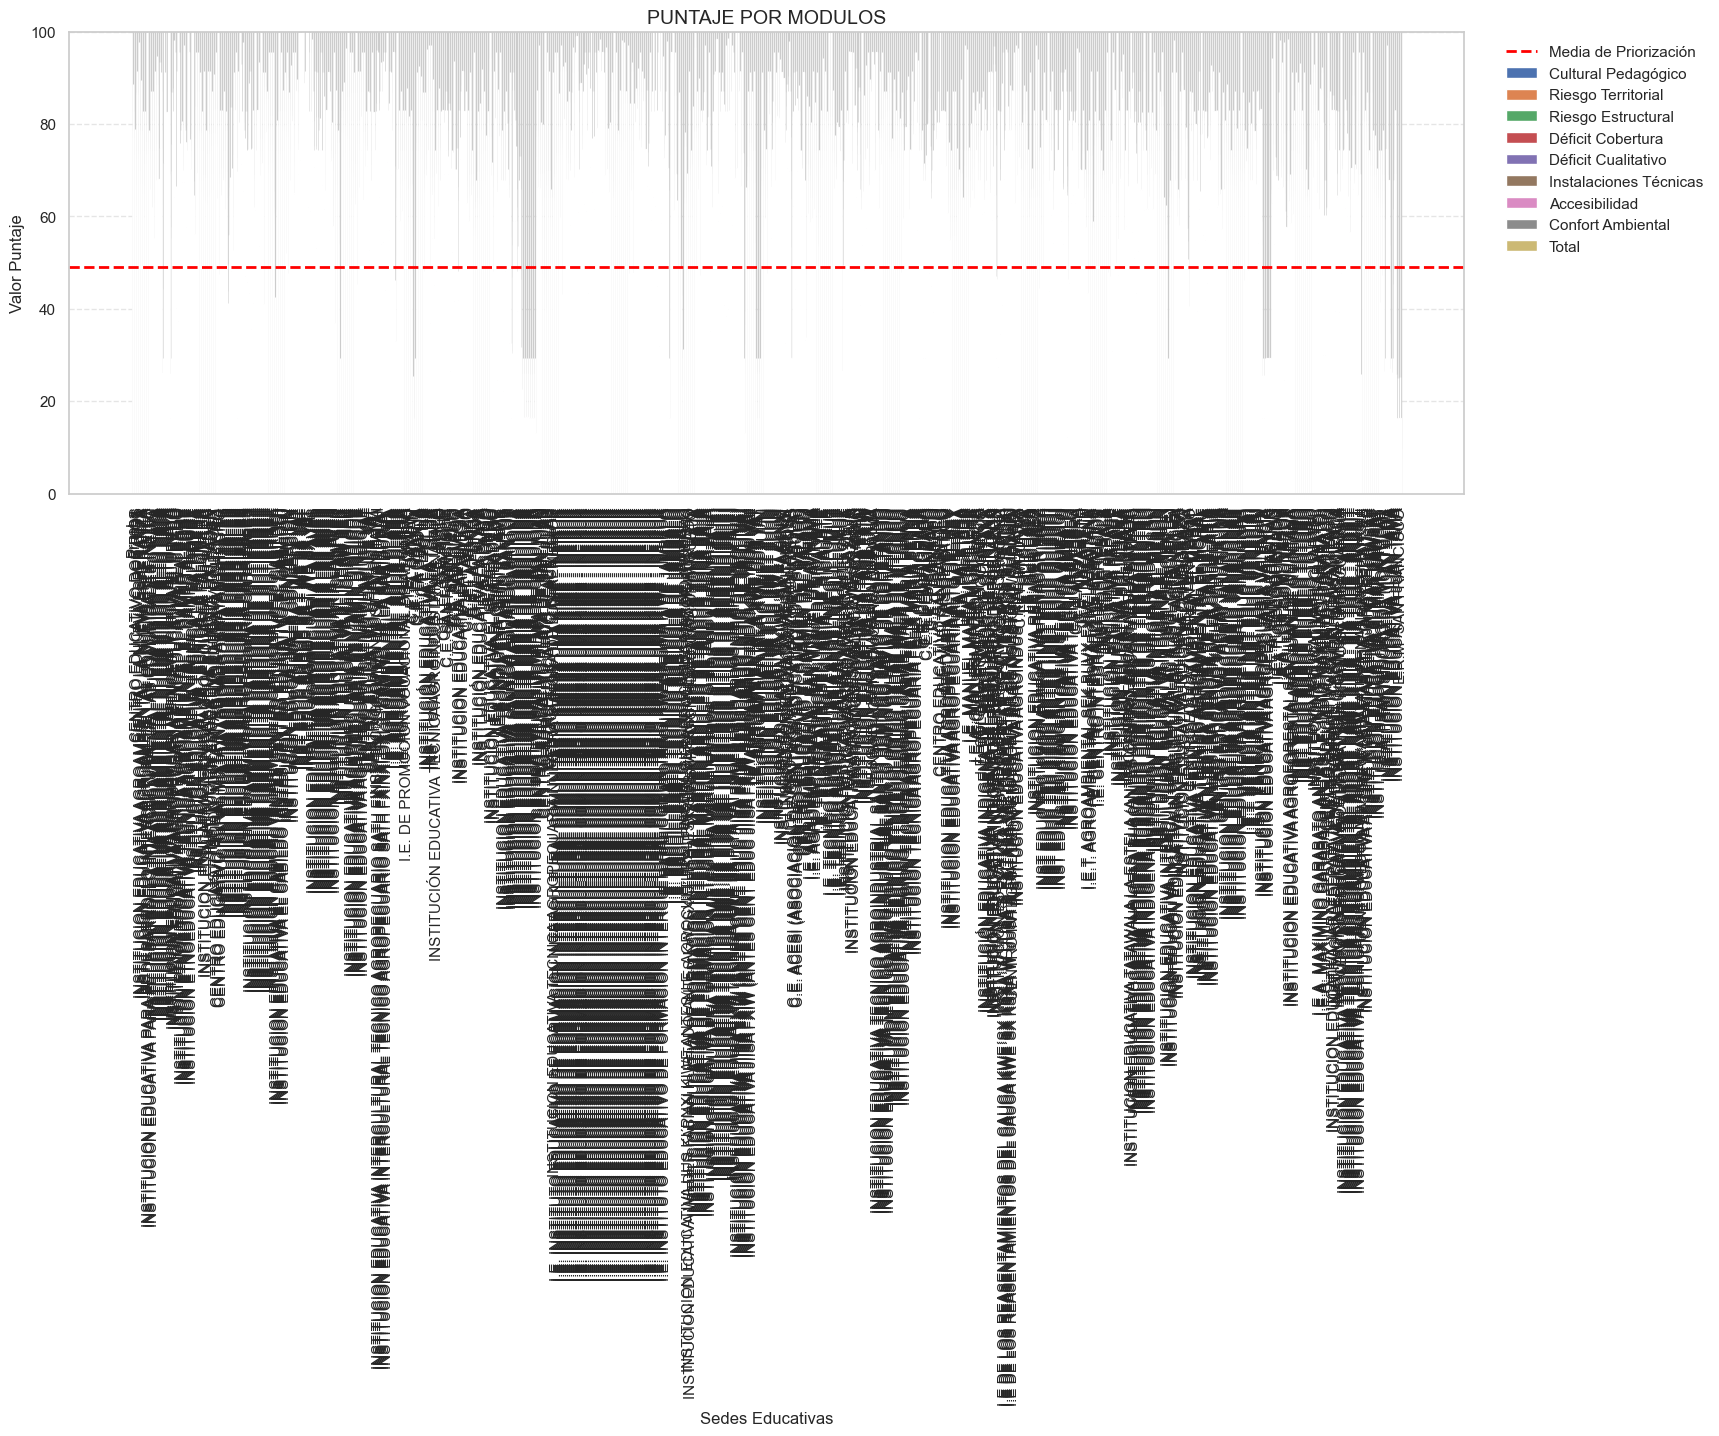

In [78]:
n = len(df['Nombre'])

# Aumentar separación entre sedes
x = np.arange(n) * 3

# Barras más delgadas
width = 0.12

plt.figure(figsize=(18,6))

plt.bar(x - 4*width, df['Puntaje_CULTURAL_PEDAGOGICO'], width, label='Cultural Pedagógico')
plt.bar(x - 3*width, df['Puntaje_RIESGO_TERRITORIAL'], width, label='Riesgo Territorial')
plt.bar(x - 2*width, df['Puntaje_RIESGO_ESTRUCTURAL'], width, label='Riesgo Estructural')
plt.bar(x - width, df['Puntaje_DEFICIT_COBERTURA'], width, label='Déficit Cobertura')
plt.bar(x, df['Puntaje_DEFICIT_CUALITATIVO'], width, label='Déficit Cualitativo')
plt.bar(x + width, df['Puntaje_INSTALACIONES_TECNICAS'], width, label='Instalaciones Técnicas')
plt.bar(x + 2*width, df['Puntaje_ACCESIBILIDAD'], width, label='Accesibilidad')
plt.bar(x + 3*width, df['Puntaje_CONFORT_AMBIENTAL'], width, label='Confort Ambiental')
plt.bar(x + 4*width, df['Puntaje_TOTAL'], width, label='Total')

plt.title('PUNTAJE POR MODULOS', fontsize=14)
plt.xlabel('Sedes Educativas')
plt.ylabel('Valor Puntaje')

plt.xticks(x, df['Nombre'], rotation=90)
plt.ylim(0,100)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.axhline(
    y=49,
    linestyle='--',
    linewidth=2,
    color='red',
    label='Media de Priorización'
)

plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')

plt.tight_layout()
plt.show()

### RESUMEN DE SEDES POR CATEGORIA 

In [79]:
# Menores de 30
sin_diligenciar = df[df['Puntaje_TOTAL'] < 30]

# Cercanas a 49 (por ejemplo ±5 puntos)
cerca_49 = df[
    (df['Puntaje_TOTAL'] >= 44) &
    (df['Puntaje_TOTAL'] <= 54)
]

# Entre 49 y 74
entre_49_74 = df[
    (df['Puntaje_TOTAL'] > 49) &
    (df['Puntaje_TOTAL'] < 74)
]

# Entre 74 y 100
entre_74_100 = df[
    (df['Puntaje_TOTAL'] >= 74) &
    (df['Puntaje_TOTAL'] <= 100)
]

print("Menor de 30:",len(sin_diligenciar))
print("Cerca de 49:",len(cerca_49))
print("Entre 49 y 74:",len(entre_49_74))
print("Entre 74 y 100:",len(entre_74_100))

Menor de 30: 47
Cerca de 49: 48
Entre 49 y 74: 522
Entre 74 y 100: 33


### GRAFICA DE RESUMEN CANTIDAD DE SEDES POR CATEGORIA

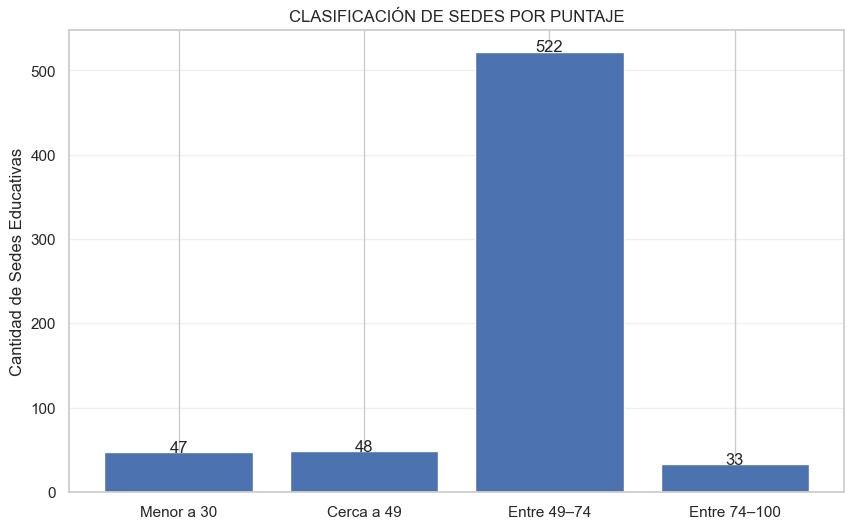

In [80]:
import matplotlib.pyplot as plt

categorias = [
    "Menor a 30",
    "Cerca a 49",
    "Entre 49–74",
    "Entre 74–100"
]

valores = [
    len(sin_diligenciar),
    len(cerca_49),
    len(entre_49_74),
    len(entre_74_100)
]

plt.figure(figsize=(10,6))

barras = plt.bar(categorias, valores)

plt.title("CLASIFICACIÓN DE SEDES POR PUNTAJE")
plt.ylabel("Cantidad de Sedes Educativas")

# etiquetas encima
for barra in barras:
    altura = barra.get_height()

    plt.text(
        barra.get_x()+barra.get_width()/2,
        altura,
        str(int(altura)),
        ha='center'
    )

plt.grid(axis='y',alpha=0.3)

plt.show()

### SEDES SIN DILIGENICIAR
##### Sedes que tiene menos del 30% de la ficha diligenciada

In [81]:
print("SEDES SIN DILIGENCIAMIENTO")
sin_diligenciar[['Nombre Sede','Puntaje_TOTAL']].sort_values('Puntaje_TOTAL').head(10)

SEDES SIN DILIGENCIAMIENTO


,Nombre Sede,Puntaje_TOTAL
642,ESCUELA RURAL MIXTA ESCALERETA,7.621981
643,E.R.M SAN FRANCISCO,7.640226
142,C.E. EL DAMIAN - SEDE PRINCIPAL,9.699322
641,ESCUELA RURAL MIXTA BOTATIERRA,9.754059
623,ESCUELA RURAL MIXTA LA SIERPE,9.754059
576,EL ENCINO,13.034191
575,LOYOLA,13.034191
574,EL PORVENIR,13.034191
525,ESCUELA RURAL MIXTA CHIRRIADERO,13.034191
577,VALENCIA (SEDE PRINCIPAL),13.043313


### SEDES ENTRE 49 Y 74 PUNTOS

In [82]:
print("SEDES ENTRE 49 Y 74 PUNTOS")
entre_49_74[['Nombre Sede', 'Zona','Resguardo', 'Municipio', 'Puntaje_TOTAL']].sort_values('Puntaje_TOTAL').head(10)

SEDES ENTRE 49 Y 74 PUNTOS


,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
481,C.E. NAZARETH - SEDE PRINCIPAL,ZONA ORIENTE,PITAYO,SILVIA,49.045907
568,ESCUELA RURAL MIXTA CRUZ CHIQUITA,ZONA SUR,SAN SEBASTíAN,SAN SEBASTIAN,49.11702
572,ESCUELA RURAL MIXTA BELLA VISTA,ZONA SUR,SAN SEBASTíAN,SAN SEBASTIAN,49.381122
580,I.E. PUEBLOQUEMADO - SEDE PRINCIPAL,ZONA SUR,RIO BLANCO,SOTARA,49.470958
49,ESCUELA RURAL MIXTA MIRAVALLE,ZONA NORTE,PAÉZ DE CORINTO,CORINTO,49.72368
174,C.E. LA FONDA - SEDE PRINCIPAL,ZONA NORTE,TACUEYO,TORIBIO,49.837236
536,CENRO DOCETE RURAL MIXTO SAN JULIAN,0,0,0,50.004354
213,ESCUELA RURAL MIXTA DE PANCHE,0,0,0,50.280111
610,ESCUELA RURAL MIXTA SAN FRANCISCO LA VUELTA,COSTA PACIFICA,SAN FRANCISCO LA VUELTA,PUERTO LOPEZ,50.318203
140,I.E. TORIBIO - SEDE PRINCIPAL,ZONA NORTE,TORIBIO,TORIBIO,50.503686


### SEDES CERCA A 49 PUNTOS RANGO DE 5%
##### Sedes con alto puntaje de priorización por estar mas cerca al puntaje mas bajo de calificación

In [83]:
print('TOP 10 SEDES CERCA A 49 PUNTOS')
cerca_49[['Nombre','Zona', 'Resguardo', 'Municipio','Puntaje_TOTAL']].sort_values('Puntaje_TOTAL').head(10).sort_values(by='Puntaje_TOTAL')

TOP 10 SEDES CERCA A 49 PUNTOS


,Nombre,Zona,Resguardo,Municipio,Puntaje_TOTAL
418,INSTITUCION EDUCATIVA AGROPECUARIA ALTO DEL REY,ZONA CENTRO,ALTO DEL REY,EL TAMBO,44.326631
183,INSTITUCION EDUCATIVA EL SESTEADERO,ZONA NORTE,TORIBIO,TORIBIO,44.544997
112,INSTITUCION EDUCATIVA AGROPECUARIA BENJAMIN DINDICUE,ZONA NORTE,MUNCHIQUE LOS TIGRES,SANTANDER DE QUILICHAO,44.711288
451,C.E. TUMBURAO,ZONA ORIENTE,TUMBURAO,SILVIA,45.060058
60,INSTITUCION EDUCATIVA CARMENCITA CARDONA DE GUTIERREZ,ZONA NORTE,PAÉZ DE CORINTO,CORINTO,45.486898
210,CENTRO EDUCATIVO PLAYA DE SAN JUAN,0,0,0,45.587897
314,I.E. AGROAMBIENTAL A´KWE ÜUS YAT,0,0,0,45.951479
401,C.E. CHICHIGUARA,ZONA CENTRO,PURACÉ,PURACE,46.062452
524,INSTITUCION EDUCATIVA INDIGENA EL MESON,ZONA UH WALA VXIC,HONDURAS,MORALES,46.366315
196,INSTITUCION EDUCATIVA SANTA MARIA DE CAQUIONA,ZONA SUR,CAQUIONA,ALMAGUER,46.460894


### SEDES ZONA NORTE MAS CERCA A 49 PUNTOS

In [84]:
print('SEDES NORTE')
cerca_49_norte = cerca_49[(cerca_49['Zona'] == 'ZONA NORTE') & (cerca_49['Puntaje_TOTAL'] >= 49)]
filtrado_cerca_49_norte = cerca_49_norte[['Código DANE Sede','Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].head(10).sort_values(by='Puntaje_TOTAL')
filtrado_cerca_49_norte

SEDES NORTE


,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
49,219212000177,ESCUELA RURAL MIXTA MIRAVALLE,ZONA NORTE,PAÉZ DE CORINTO,CORINTO,49.72368
174,219821000400,C.E. LA FONDA - SEDE PRINCIPAL,ZONA NORTE,TACUEYO,TORIBIO,49.837236
140,119821000031,I.E. TORIBIO - SEDE PRINCIPAL,ZONA NORTE,TORIBIO,TORIBIO,50.503686
53,219212000339,COLEGIO RURAL AGROPECUARIO CARRIZALES (E.R.M. CARRIZALES),ZONA NORTE,PAÉZ DE CORINTO,CORINTO,51.550053
179,219821000426,CENTRO DOCENTE RURAL MIXTO BELEN,ZONA NORTE,TORIBIO,TORIBIO,51.620239
13,219110001438,ESCUELA RURAL MIXTA LA VEGA NAYA,ZONA NORTE,NAYA,BUENOS AIRES,52.150773
162,219821000175,C.E. SAN DIEGO - SEDE PRINCIPAL,ZONA NORTE,TACUEYO,TORIBIO,52.889927
61,219212000126,ESCUELA RURAL MIXTA LOS ALPES,ZONA NORTE,PAÉZ DE CORINTO,CORINTO,53.947335
17,219110001756,ESCUELA RURAL MIXTA RIO MINA - SEDE PRINCIPAL,ZONA NORTE,NAYA,BUENOS AIRES,53.985241


In [85]:
# Guardar datos en excel zona norte

filtrado_cerca_49_norte.to_excel("Sedes_a_priorizar_Zona_Norte.xlsx", index=False)


### SEDES ZONA CENTRO MAS CERCA A 49 PUNTOS 

In [86]:
print('SEDES CENTRO')
cerca_49_centro = cerca_49[cerca_49['Zona'] == 'ZONA CENTRO']
filtrado_cerca_49_centro = cerca_49_centro[['Código DANE Sede', 'Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].head(10).sort_values(by='Puntaje_TOTAL')
filtrado_cerca_49_centro

SEDES CENTRO


,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
418,219256000239,I.E. AGROPECUARIA ALTO DEL REY - SEDE PRINCIPAL,ZONA CENTRO,ALTO DEL REY,EL TAMBO,44.326631
401,219585000665,ESCUELA RURAL MIXTA CHAPIO,ZONA CENTRO,PURACÉ,PURACE,46.062452
402,219585000479,ESCUELA RURAL MIXTA TABIO,ZONA CENTRO,PURACÉ,PURACE,47.486749
440,219001001290,SEDE EL CANELO PARCELACION,ZONA CENTRO,QUINTANA,POPAYAN,51.329809
415,219256001600,ESCUELA LA PRADERA,ZONA CENTRO,ALTO DEL REY,EL TAMBO,52.682796


In [87]:
# Guardar datos Zona centro A

filtrado_cerca_49_centro.to_excel("Sedes_a_priorizar_Zona_Centro_1.xlsx", index=False)

In [88]:
entre_49_74_centro = entre_49_74[entre_49_74['Zona'] == 'ZONA CENTRO']
filtrado_cerca_49_centro_2 = entre_49_74_centro[['Código DANE Sede','Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].head(5).sort_values(by='Puntaje_TOTAL')
filtrado_cerca_49_centro_2

,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
405,219585000673,C.E. PISANRABO - SEDE PRINCIPAL,ZONA CENTRO,KOKONUKO,PURACE,54.084472
399,219585000142,C.E. CHICHIGUARA,ZONA CENTRO,PURACÉ,PURACE,54.334391
406,219585000622,ESCUELA RURAL MIXTA COBALO,ZONA CENTRO,KOKONUKO,PURACE,55.361902
400,219585000011,ESCUELA RURAL MIXTA ALTO DE ANAMBIO,ZONA CENTRO,PURACÉ,PURACE,65.467007
403,219585000100,C.E. EL EMPALIZADO - SEDE PRINCIPAL,ZONA CENTRO,PALETARÁ,PURACE,68.667295


In [89]:
filtrado_cerca_49_centro_2.to_excel("Sedes_a_priorizar_Zona_Centro_2.xlsx", index=False)

### SEDES ZONA TIERRADENTRO MAS CERCA A 49 PUNTOS

SEDES JUAN TAMA

In [90]:
print('SEDES TIERRADENTRO (A.C.I Juan Tama)')
cerca_49_tierradentro = cerca_49[(cerca_49['Zona'] == 'TIERRA DENTRO') & (cerca_49['Municipio'] == 'INZA')]
filtrado_cerca_49_juan_tama = cerca_49_tierradentro[['Código DANE Sede', 'Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].head().sort_values(by='Puntaje_TOTAL')
filtrado_cerca_49_juan_tama

SEDES TIERRADENTRO (A.C.I Juan Tama)


,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
315,219355000291,ESCUELA RURAL MIXTA EL ESCOBAL,TIERRA DENTRO,LA GAITANA JUAN TAMA,INZA,47.06541
320,219355000046,ESCUELA RURAL MIXTA LOMA ALTA,TIERRA DENTRO,SAN ANDRÉS,INZA,51.303006


In [91]:
# Guardar datos de Juan Tama #1
filtrado_cerca_49_juan_tama.to_excel("Sedes_a_priorizar_Juan_Tama_1.xlsx", index=False)

In [92]:
entre_49_74_tierradentro = entre_49_74[entre_49_74['Zona'] == 'TIERRA DENTRO']
filtrado_cerca_49_juan_tama_2 = entre_49_74_tierradentro[['Código DANE Sede','Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].head(9).sort_values(by='Puntaje_TOTAL')
filtrado_cerca_49_juan_tama_2

,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
320,219355000046,ESCUELA RURAL MIXTA LOMA ALTA,TIERRA DENTRO,SAN ANDRÉS,INZA,51.303006
306,219355000062,ESCUELA RURAL MIXTA LOS NARANJOS DEL CABUYO,TIERRA DENTRO,YAQUIVA,INZA,62.751328
321,219355000143,ESCUELA RURAL MIXTA EL PICACHO,TIERRA DENTRO,SAN ANDRÉS,IZA,63.55478
319,219355001361,E.R.M. PIIYA THE WE´SX UUS YAT,TIERRA DENTRO,SAN ANTONIO DE PEDREGAL,INZA,64.528506
312,219355800000,ESCUELA RURAL MIXTA ÜUS DXI`CAMINO DE SABIDURIA,TIERRA DENTRO,YAQUIVA,INZA,65.785444
308,219355000313,ESCUELA RURAL MIXTA CHICHUCUE,TIERRA DENTRO,YAQUIVA,INZA,66.644698
313,419355000223,ESCUELA RURAL MIXTA YAQUIVA,TIERRA DENTRO,YAQUIVA,INZA,72.108427
307,219355000283,ESCUELA RURAL MIXTA LA MILAGROSA,TIERRA DENTRO,YAQUIVA,INZA,72.413189
309,219355000321,ESCUELA RURAL MIXTA COSCURO,TIERRA DENTRO,YAQUIVA,INZA,73.664655


In [93]:
# Guardar datos de Juan Tama #2
filtrado_cerca_49_juan_tama_2.to_excel("Sedes_a_priorizar_Juan_Tama_2.xlsx", index=False)

SEDES Nasa Çxhâçxha

In [94]:
print('SEDES TIERRADENTRO (Nasa Çxhâçxha)')
cerca_49_tierradentro = cerca_49[(cerca_49['Zona'] == 'TIERRA DENTRO') & (cerca_49['Municipio'] == 'PAEZ')]
filtrado_cerca_49_nasacxacxa_1 = cerca_49_tierradentro[['Código DANE Sede','Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].head().sort_values(by='Puntaje_TOTAL')
filtrado_cerca_49_nasacxacxa_1

SEDES TIERRADENTRO (Nasa Çxhâçxha)


,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
391,219517001670,ESCUELA RURAL MIXTA TIERRAS BLANCAS,TIERRA DENTRO,LAME,PAEZ,47.043181
340,219517000169,ESCUELA EL CARMEN DEL SALADO,TIERRA DENTRO,BELALCAZAR,PAEZ,51.666385
348,219517000428,CENTRO DOCENTE LA HONDA,TIERRA DENTRO,RICAURTE,PAEZ,53.888238


In [95]:
# Guardar datos Nasa Cxa Cxa #1
filtrado_cerca_49_nasacxacxa_1.to_excel("Sedes_a_priorizar_Nasa_CxaCxa.xlsx")

In [96]:
entre_49_74_tierradentro_2 = entre_49_74[(entre_49_74['Zona'] == 'TIERRA DENTRO') & (entre_49_74['Municipio'] == 'PAEZ')]
filtrado_cerca_49_nasacxacxa_2 = entre_49_74_tierradentro_2[['Código DANE Sede','Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].head(8).sort_values(by='Puntaje_TOTAL')
filtrado_cerca_49_nasacxacxa_2

,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
340,219517000169,ESCUELA EL CARMEN DEL SALADO,TIERRA DENTRO,BELALCAZAR,PAEZ,51.666385
339,219517800009,ESCUELA RURAL MIXTA MESA DE BELALCAZAR,TIERRA DENTRO,BELALCAZAR,PAEZ,57.878276
343,219517000045,ESCUELA RURAL MIXTA SAN ANTONIO DEL SALADO,TIERRA DENTRO,BELALCAZAR,PAEZ,58.790418
344,219517000568,ESCUELA RURAL MIXTA AGUA BENDITA,TIERRA DENTRO,AVIRAMA,PAEZ,59.568535
342,219517001076,ESCUELA RURAL MIXTA POTRERO DEL BARRO,TIERRA DENTRO,BELALCAZAR,PAEZ,60.769742
337,219517000550,ESCUELA RURAL MIXTA EL RODEO,TIERRA DENTRO,BELALCAZAR,PAEZ,68.719269
338,219517000720,ESCUELA RURAL MIXTA LA MARIA,TIERRA DENTRO,TÁLAGA,PAEZ,70.043541
336,219517000151,C.E. ACESI (ASOCIACION DE CENTROS EDUCATIVOS DEL SIMBOLA) - SEDE PRINCIPAL,TIERRA DENTRO,BELALCAZAR,PAEZ,72.499334


In [97]:
# Guardar datos Nasa Cxa Cxa #2
filtrado_cerca_49_nasacxacxa_2.to_excel("Sedes_a_priorizar_Nasa_CxaCxa_2.xlsx")

### SEDES PUEBLO YANACONA MAS CERCA A 49 PUNTOS

In [98]:
print('SEDES PUEBLO YANACONA')
cerca_49_sur = cerca_49[(cerca_49['Zona'] == 'ZONA SUR') & (cerca_49['Pueblo'] == 'Pueblo Yanakuna')]
filtrado_cerca_49_yanacona_1 = cerca_49_sur[['Código DANE Sede','Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].sort_values(by='Puntaje_TOTAL').head(4)
filtrado_cerca_49_yanacona_1

SEDES PUEBLO YANACONA


,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
196,219022000341,ESCUELA RURAL MIXTA BALCONCRUZ,ZONA SUR,CAQUIONA,ALMAGUER,46.460894
568,219693000361,ESCUELA RURAL MIXTA CRUZ CHIQUITA,ZONA SUR,SAN SEBASTíAN,SAN SEBASTIAN,49.11702
572,219693000612,ESCUELA RURAL MIXTA BELLA VISTA,ZONA SUR,SAN SEBASTíAN,SAN SEBASTIAN,49.381122
580,219760000100,I.E. PUEBLOQUEMADO - SEDE PRINCIPAL,ZONA SUR,RIO BLANCO,SOTARA,49.470958


In [99]:
# Guardar datos de Yanacona
filtrado_cerca_49_yanacona_1.to_excel("Sedes_a_priorizar_Yanacona_1.xlsx", index=False)

In [100]:
print('SEDES EDUCATIVAS PUEBLO YANACONA ENTRE 49 Y 74 PUNTOS')
entre_49_74_sur_2 = entre_49_74[(entre_49_74['Zona'] == 'ZONA SUR') & (entre_49_74['Puntaje_TOTAL'] < 60)]
filtrado_cerca_49_yanacona_2 = entre_49_74_sur_2[['Código DANE Sede', 'Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].head(6).sort_values(by='Puntaje_TOTAL')
filtrado_cerca_49_yanacona_2

SEDES EDUCATIVAS PUEBLO YANACONA ENTRE 49 Y 74 PUNTOS


,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
540,219392000102,ESCUELA RURAL MIXTA LOS ROBLES,ZONA SUR,EL MORAL,LA SIERRA,51.275798
541,219392000391,ESCUELA RURAL MIXTA CAMPOBELLO,ZONA SUR,EL MORAL,LA SIERRA,56.98918
211,219100000662,CENTRO EDUCATIVO PLACETILLAS,ZONA SUR,SAN JUAN,BOLIVAR,57.815419
539,219392000021,ESCUELA RURAL MIXTA EL SALERO,ZONA SUR,EL MORAL,LA SIERRA,58.209871
542,219392000552,CENTRO DOCENTE SANTA MARTA,ZONA SUR,EL MORAL,LA SIERRA,59.703508
538,119392001147,ESCUELA RURAL MIXTA AMOR POR LO NUESTRO,ZONA SUR,PUERTAS DEL MACIZO,LA SIERRA,59.932447


In [101]:
# Guardar datos de Yanacona_2
filtrado_cerca_49_yanacona_2.to_excel("Sedes_a_priorizar_Yanacona_2.xlsx", index=False)

### SEDES EDUCATIVAS SAT´H TAMA KIWE CERCA DE 49 PUNTOS 
##### No hay sedes que esten en el rango del 5% a 49 puntos

In [102]:
print('SEDES SATH TAMA KIWE CERCA A 49 PUNTOS')
cerca_49_stk = cerca_49[(cerca_49['Zona'] == 'ZONA SATH TAMA KIWE')]
cerca_49_stk[['Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']]

SEDES SATH TAMA KIWE CERCA A 49 PUNTOS


,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL


### SEDES EDUCATIVAS SAT´H TAMA KIWE ENTRE 49 Y 74 PUNTOS 

In [103]:
print('SEDES EDUCATIVAS SATH TAMA KIWE ENTRE 49 Y 74 PUNTOS')
entre_49_74_stk = entre_49_74[(entre_49_74['Zona'] == 'ZONA SATH TAMA KIWE') & (entre_49_74['Puntaje_TOTAL'] < 60)]
filtro_sedes_stk = entre_49_74_stk[['Código DANE Sede','Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].head(6).sort_values(by='Puntaje_TOTAL')
filtro_sedes_stk

SEDES EDUCATIVAS SATH TAMA KIWE ENTRE 49 Y 74 PUNTOS


,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
254,219137001260,CENTRO DOCENTE RURAL MIXTO SAN JOSE DE LOS MONOS,ZONA SATH TAMA KIWE,PUEBLO NUEVO,CALDONO,54.707712
244,219137001111,CENTRO DOCENTE RURAL MIXTO SAN PEDRO,ZONA SATH TAMA KIWE,PUEBLO NUEVO,CALDONO,56.005284
222,219137000204,INSTITUTO EDUCATIVO TÉCNICO AGRÍCOLA KWESX DXIJ PLAN DE ZÚÑIGA,ZONA SATH TAMA KIWE,SAN LORENZO,CALDONO,56.040618
264,219137001529,ESC RUR MIX LA LAGUNA BILINGUE,ZONA SATH TAMA KIWE,LA LAGUNA,CALDONO,57.191077
251,219137001227,CENTRO DOCENTE VILLA RICA,ZONA SATH TAMA KIWE,LA AGUADA - SAN ANTONIO,CALDONO,58.230024


In [104]:
filtro_sedes_stk.to_excel("Sedes_a_priorizar_Sat´h_Tama_Kiwe.xlsx", index=False)

### SEDES EDUCATIVAS COTAINDOC CERCA DE LOS 49 PUNTOS

In [105]:
print('SEDES ZONA ORIENTE COTAINDOC')
cerca_49_oriente = cerca_49[(cerca_49['Zona'] == 'ZONA ORIENTE')]
filtro_COTAINDOC = cerca_49_oriente[['Código DANE Sede', 'Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].sort_values(by='Puntaje_TOTAL').head(10)
filtro_COTAINDOC

SEDES ZONA ORIENTE COTAINDOC


,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
451,219743000031,CRISTO REY - SEDE PRINCIPAL,ZONA ORIENTE,TUMBURAO,SILVIA,45.060058
481,219743000511,C.E. NAZARETH - SEDE PRINCIPAL,ZONA ORIENTE,PITAYO,SILVIA,49.045907
503,219824000427,CENTRO DOCENTE RURAL MIXTO EL BAHO,ZONA ORIENTE,POLINDARA,TOTORO,50.807612
496,219824000095,ESCUELA SAN ANTONIO,ZONA ORIENTE,PANIQUITA,TOTORO,50.904234
456,419743001096,CENTRO DOCENTE RURAL MIXTO GOLONDRINAS,ZONA ORIENTE,QUICHAYA,SILVIA,51.787051
508,219824800017,LA PRIMAVERA,ZONA ORIENTE,PANIQUITA,TOTORO,53.463491


In [106]:
# Guardar datos COTAINDOC
filtro_COTAINDOC.to_excel("Sedes_a_priorizar_COTAINDOC.xlsx", index=False)

### SEDES PUEBLO TOTOROEZ CERCA DE LOS 49 PUNTOS

In [107]:
print('SEDES EDUCATIVAS PUEBLO TOTOROEZ')
cerca_49_pt = cerca_49[(cerca_49['Zona'] == 'PUEBLO TOTOROEZ') ]
filtro_totoro_1 = cerca_49_pt[['Código DANE Sede','Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].sort_values(by='Puntaje_TOTAL')
filtro_totoro_1

SEDES EDUCATIVAS PUEBLO TOTOROEZ


,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
596,219824000494,CENT DOC RUR MIX PUENTE TIERRA,PUEBLO TOTOROEZ,TOTORÓ,TOTORO,52.015348


In [108]:
filtro_totoro_1.to_excel("Sedes_a_priorizar_Totoro_1.xlsx", index=False)

### SEDES EDUCATIVAS PUEBLO TOTOROEZ ENTRE 49 Y 74 PUNTOS

In [109]:
print('SEDES EDUCATIVAS PUEBLO TOTOROEZ ENTRE 49 Y 74 PUNTOS')
entre_49_74_pt = entre_49_74[(entre_49_74['Zona'] == 'PUEBLO TOTOROEZ')]
filtro_totoro_2 = entre_49_74_pt[['Código DANE Sede','Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].head(4).sort_values(by='Puntaje_TOTAL')
filtro_totoro_2

SEDES EDUCATIVAS PUEBLO TOTOROEZ ENTRE 49 Y 74 PUNTOS


,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
593,219824000320,CENTRO DOCENTE RURAL MIXTO NUEVA ORLEANS,PUEBLO TOTOROEZ,TOTORÓ,TOTORO,63.414354
590,219824000010,ESCUELA RURAL MIXTA EL COFRE,PUEBLO TOTOROEZ,TOTORÓ,TOTORO,64.524294
592,219824000273,CENTRO DOCENTE RURAL MIXTO MIRAFLORES,PUEBLO TOTOROEZ,TOTORÓ,TOTORO,71.277503
591,219824000044,CENTRO DOCENTE EL CARMEN ZABALETAS,PUEBLO TOTOROEZ,TOTORÓ,TOTORO,73.787677


In [110]:
filtro_totoro_2.to_excel("Sedes_a_priorizar_Totoro_2.xlsx", index=False)

### SEDES EDUCATIVAS UH WALA VXIC CERCA DE 49 PUNTOS

In [111]:
cerca_49_uwv = cerca_49[(cerca_49['Zona'] == 'ZONA UH WALA VXIC')]
filtro_uwv_1 = cerca_49_uwv[['Código DANE Sede','Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].sort_values(by='Puntaje_TOTAL')
filtro_uwv_1

,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
524,219473006717,ESCUELA RURAL MIXTA BELEN,ZONA UH WALA VXIC,HONDURAS,MORALES,46.366315
526,219473000531,ESCUELA RURAL MIXTA PUEBLILLO,ZONA UH WALA VXIC,HONDURAS,MORALES,47.049232


In [112]:
filtro_uwv_1.to_excel("Sedes_a_priorizar_UhWalaVixc_1.xlsx", index=False)

In [113]:
entre_49_74_uwv = entre_49_74[(entre_49_74['Zona'] == 'ZONA UH WALA VXIC')]
filtro_uwv_2 = entre_49_74_uwv[['Código DANE Sede','Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].sort_values(by='Puntaje_TOTAL').head(8)
filtro_uwv_2

,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
533,219473000760,ESCUELA AA. CIPO LA LIBERIA,ZONA UH WALA VXIC,CHIMBORAZO,MORALES,57.413122
531,419473006392,ESCUELA RURAL MIXTA SAMARIA,ZONA UH WALA VXIC,AGUA NEGRA,MORALES,58.209397
512,219473000719,ESCUELA RURAL MIXTA LAS BRISAS,ZONA UH WALA VXIC,HONDURAS,MORALES,60.451059
509,219473000018,ESCUELA RURAL DE TIERRA DENTRO,ZONA UH WALA VXIC,HONDURAS,MORALES,60.529775
527,219473000573,ESCUELA RURAL MIXTA MEDELLIN,ZONA UH WALA VXIC,HONDURAS,MORALES,61.121647
517,219473006687,KWE´SX KIWE,ZONA UH WALA VXIC,HONDURAS,MORALES,61.598948
514,219473000743,ESCUELA RURAL MIXTA EL JORDAN,ZONA UH WALA VXIC,HONDURAS,MORALES,61.73415
520,219473000221,ESCUELA RURAL MIXTA SAN JOSE DE CAUCA,ZONA UH WALA VXIC,HONDURAS,MORALES,61.906177


In [114]:
filtro_uwv_2.to_excel("Sedes_a_priorizar_UhWalaVixc_2.xlsx", index=False)

### SEDES ZONA NASA UUS CERCA DE 49 PUNTOS
##### No hay sedes cerca de 49 puntos

In [115]:

cerca_49_nu = cerca_49[(cerca_49['Zona'] == 'ZONA NASA UUS')]
cerca_49_nu[['Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].head().sort_values(by='Puntaje_TOTAL')

,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL


### SEDES ZONA NASA USS ENTRE 49 Y 74 PUNTOS

In [116]:

print('SEDES NASA USS')
entre_49_74_nu = entre_49_74[(entre_49_74['Zona'] == 'ZONA NASA UUS')]
filtro_nasauus = entre_49_74_nu[['Código DANE Sede','Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].head(4).sort_values(by='Puntaje_TOTAL')
filtro_nasauus

SEDES NASA USS


,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
442,219130003658,ESCUELA RURAL MIXTA SAN JOSE DEL GUAYABAL,ZONA NASA UUS,CXAYU CE FXIW,CAJIBIO,59.702411
446,219760000690,E.R.M. EL PEÑÓN,ZONA NASA UUS,EL PEÑON,SOTARA,63.347542
445,219473006491,E.R.M. SEMILLERO DE NIÑOS PAECES (LUUCX FXIW) - SEDE PRINCIPAL,ZONA NASA UUS,MUSSE UKWE,MORALES,73.285351
443,219130003739,PATHYU LUUCX,ZONA NASA UUS,PATH YU,CAJIBIO,73.857191


In [117]:
filtro_nasauus.to_excel("Sedes_a_priorizar_NasaUus.xlsx", index=False)

### DESCRIPCIÓN ESTADISTICA DE LOS DATOS 

In [118]:
puntaje = df['Puntaje_TOTAL']

print("Cantidad:", puntaje.count())
print("Promedio:", round(puntaje.mean(),2))
print("Mediana:", round(puntaje.median(),2))
print("Moda:", puntaje.mode().values)
print("Mínimo:", puntaje.min())
print("Máximo:", puntaje.max())

print("Desviación estándar:",
    round(puntaje.std(),2))

print("Varianza:",
    round(puntaje.var(),2))

print("Cuartil 25:",
    round(puntaje.quantile(0.25),2))

print("Cuartil 75:",
    round(puntaje.quantile(0.75),2))

print("P10:",puntaje.quantile(.10))
print("P25:",puntaje.quantile(.25))
print("P50:",puntaje.quantile(.50))
print("P75:",puntaje.quantile(.75))
print("P90:",puntaje.quantile(.90))

Cantidad: 644
Promedio: 59.86
Mediana: 63.88
Moda: [13.088927586206896 13.098050431034483]
Mínimo: 7.621980603448275
Máximo: 83.86982344827587
Desviación estándar: 14.85
Varianza: 220.62
Cuartil 25: 57.71
Cuartil 75: 68.82
P10: 40.97848614655173
P25: 57.71243071120689
P50: 63.87596275862069
P75: 68.82077790948276
P90: 72.1222207025862


### GRAFICO DE TENDENCIAS DIVIDIDO EN PERCENTILES

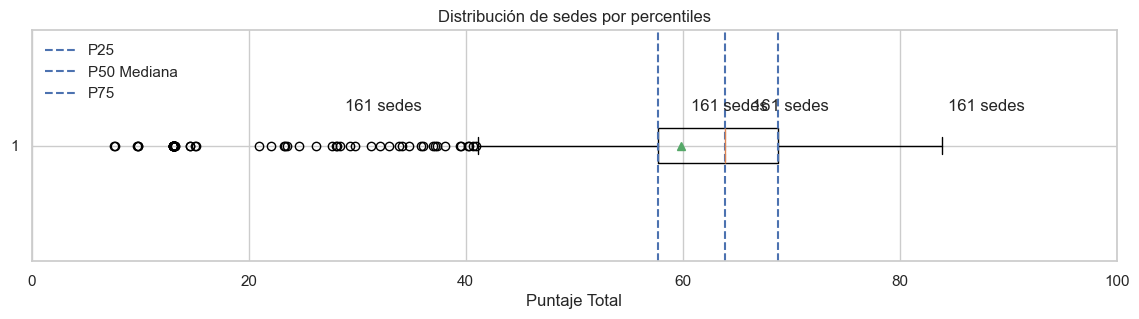

In [119]:
import matplotlib.pyplot as plt

puntaje = df['Puntaje_TOTAL'].dropna()

# Calcular percentiles
p25 = puntaje.quantile(0.25)
p50 = puntaje.quantile(0.50)
p75 = puntaje.quantile(0.75)

# Cantidad de sedes por rango
q1 = len(puntaje[puntaje <= p25])

q2 = len(
    puntaje[
        (puntaje > p25) &
        (puntaje <= p50)
    ]
)

q3 = len(
    puntaje[
        (puntaje > p50) &
        (puntaje <= p75)
    ]
)

q4 = len(puntaje[puntaje > p75])

plt.figure(figsize=(14,3))

plt.boxplot(
    puntaje,
    vert=False,
    showmeans=True
)

# líneas de percentiles
plt.axvline(p25, linestyle='--', label='P25')
plt.axvline(p50, linestyle='--', label='P50 Mediana')
plt.axvline(p75, linestyle='--', label='P75')

# texto con cantidades
plt.text(p25/2,
        1.15,
        f"{q1} sedes")

plt.text((p25+p50)/2,
        1.15,
        f"{q2} sedes")

plt.text((p50+p75)/2,
        1.15,
        f"{q3} sedes")

plt.text((p75+100)/2,
        1.15,
        f"{q4} sedes")

plt.xlim(0,100)

plt.xlabel("Puntaje Total")
plt.title("Distribución de sedes por percentiles")

plt.legend()

plt.show()